In [50]:
# Install dependency dengan versi terpin (Python 3.11+)
%pip install -q pandas==3.0.6 numpy==2.3.2 matplotlib==3.10.8 requests==2.32.5 pyarrow==21.0.0 lightgbm==4.6.0 scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [51]:
# import library
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## 1. Data acquisition dan loading

Dataset kompetisi tersedia di `dataset/`. Metadata publik untuk 20 judul yang tidak tercantum pada katalog lokal tersimpan di `external_data/missing_movies_metadata.csv`; sumber, endpoint, tanggal pengambilan, atribusi, dan audit kecocokan judul dicatat di `external_data/`. Akuisisi ulang dapat dilakukan melalui `scripts/build_pipeline.py --fetch-metadata` dengan variabel TMDB di `.env`.

In [52]:

DATASET_DIR = Path("dataset")
SUPPORTED_EXTENSIONS = {".csv"}

datasets = {}

for file_path in sorted(DATASET_DIR.iterdir()):
    if not file_path.is_file() or file_path.suffix.lower() not in SUPPORTED_EXTENSIONS:
        continue

    try:
        extension = file_path.suffix.lower()
        if extension == ".csv":
            data = pd.read_csv(file_path)
        elif extension in {".xlsx", ".xls"}:
            data = pd.read_excel(file_path)
        elif extension == ".json":
            data = pd.read_json(file_path)
        else:
            data = pd.read_parquet(file_path)

        datasets[file_path.stem] = data
        print(f"\n{'=' * 80}\nDataset: {file_path.name}")
        print(f"Ukuran: {data.shape[0]:,} baris x {data.shape[1]:,} kolom")
        print("\nTipe data:")
        print(data.dtypes)
        print("\nMissing values:")
        missing = data.isna().sum().sort_values(ascending=False)
        print(missing[missing > 0] if missing.any() else "Tidak ada missing values")
        print("\nDuplikat:")
        print(data.duplicated().sum())
        print("\nStatistik numerik:")
        display(data.describe().T)
        print("\nLima baris pertama:")
        display(data.head())
    except Exception as error:
        print(f"Gagal memuat {file_path.name}: {error}")

print(f"\nTotal dataset berhasil dimuat: {len(datasets)}")
print("Nama dataset:", list(datasets.keys()))


Dataset: holidays.csv
Ukuran: 366 baris x 5 kolom

Tipe data:
date            str
day_tipe        str
holiday_tipe    str
holiday_name    str
holiday_tier    str
dtype: object

Missing values:
holiday_name    348
dtype: int64

Duplikat:
0

Statistik numerik:


,count,unique,top,freq
date,366,366,2025-04-01,1
day_tipe,366,3,weekday,210
holiday_tipe,366,2,normal,348
holiday_name,18,17,Idulfitri 1447 H,2
holiday_tier,366,3,normal,332



Lima baris pertama:


,date,day_tipe,holiday_tipe,holiday_name,holiday_tier
0,2025-04-01,weekday,holiday,Idulfitri 1446 H,major
1,2025-04-02,weekday,normal,NaN,major
2,2025-04-03,weekday,normal,NaN,major
3,2025-04-04,friday,normal,NaN,major
4,2025-04-05,weekend,normal,NaN,normal



Dataset: movies.csv
Ukuran: 397 baris x 7 kolom

Tipe data:
original_title    str
age_rating        str
genre             str
producer          str
director          str
writer            str
casts             str
dtype: object

Missing values:
age_rating    3
dtype: int64

Duplikat:
0

Statistik numerik:


...


Dataset: train.csv
Ukuran: 138,959 baris x 7 kolom

Tipe data:
date_show              str
cinema_ids             str
city_name              str
movie_title            str
total_ticket         int64
occupation_rate    float64
total_show           int64
dtype: object

Missing values:
Tidak ada missing values

Duplikat:
0

Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
total_ticket,138959.0,354.122072,725.927987,1.0,69.00,161.00,361.00,32845.0
occupation_rate,138959.0,28.331061,22.618841,0.0,12.36,21.84,37.01,100.0
total_show,138959.0,7.730921,11.005488,1.0,3.00,5.00,8.00,285.0



Lima baris pertama:


,date_show,cinema_ids,city_name,movie_title,total_ticket,occupation_rate,total_show
0,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,A WORKING MAN,487,31.07,18
1,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,JUMBO,649,23.69,19
2,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,KOMANG,389,9.55,22
3,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,NE ZHA 2,101,70.03,3
4,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,NORMA: ANTARA MERTUA DAN MENANTU,411,17.76,13



Total dataset berhasil dimuat: 7
Nama dataset: ['holidays', 'movies', 'sample_submission', 'test', 'test_history', 'ticket_prices', 'train']


## 2. Preprocessing dan pemeriksaan kualitas

Cell berikut memeriksa konsistensi kunci, tanggal, dan kelengkapan antar-sumber sebelum analisis.

data yg missing sangat sedikit, termasuk lengkap.

## 3. Exploratory data analysis

Analisis berikut meninjau skala target, kalender/libur, karakter cluster, harga, genre, serta anomali historis.

In [53]:
# Validasi key dan kelengkapan data antar dataset
train = datasets["train"].copy()
test_history = datasets["test_history"].copy()
test = datasets["test"].copy()
movies = datasets["movies"].copy()
ticket_prices = datasets["ticket_prices"].copy()
holidays = datasets["holidays"].copy()

for data, date_column in [
    (train, "date_show"),
    (test_history, "date_show"),
    (test, "date_show"),
    (holidays, "date"),
]:
    data[date_column] = pd.to_datetime(data[date_column])

# 1. Cinema cluster: histori vs periode test
history_cinema_ids = set(train["cinema_ids"]) | set(test_history["cinema_ids"])
test_cinema_ids = set(test["cinema_ids"])
print("Cinema IDs hanya muncul di histori:", len(history_cinema_ids - test_cinema_ids))
print("Cinema IDs hanya muncul di test:", len(test_cinema_ids - history_cinema_ids))
print("Cinema IDs muncul di keduanya:", len(history_cinema_ids & test_cinema_ids))

# 2. Movie title: exact match dan kandidat setelah normalisasi sederhana
normalize_title = lambda series: (
    series.astype("string")
    .str.upper()
    .str.replace(r"\(\s*(2D|3D|IMAX|DUBBING)\s*\)", "", regex=True)
    .str.replace(r"\b(2D|3D|IMAX|DUBBING)\b", "", regex=True)
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Identity remains the exact source title; normalized values are metadata join keys only.
for frame in (train, test_history, test):
    frame["movie_title_key"] = frame["movie_title"]
    frame["movie_title_norm"] = normalize_title(frame["movie_title"])
movies["movie_title_norm"] = normalize_title(movies["original_title"])

movie_titles = set(movies["original_title"].dropna())
test_titles = set(test["movie_title"].dropna())
missing_exact_titles = sorted(test_titles - movie_titles)
print("\\nMovie title test yang tidak exact-match ke movies.csv:", len(missing_exact_titles))
print(missing_exact_titles[:20])

normalized_movie_titles = set(normalize_title(movies["original_title"].dropna()))
normalized_test_titles = normalize_title(pd.Series(missing_exact_titles))
resolved_after_normalization = set(normalized_test_titles) & normalized_movie_titles
print("Kandidat yang match setelah normalisasi format/spasi:", len(resolved_after_normalization))
print("Masih tidak ditemukan setelah normalisasi:", len(set(normalized_test_titles) - normalized_movie_titles))

# 3. Konsistensi nama kota
city_sources = {
    "train": train["city_name"],
    "test": test["city_name"],
    "ticket_prices": ticket_prices["city_name"],
}
normalized_city_sets = {
    name: set(values.dropna().astype("string").str.upper().str.strip())
    for name, values in city_sources.items()
}
all_cities = set.union(*normalized_city_sets.values())
city_comparison = pd.DataFrame({
    name: sorted(all_cities).copy() for name in normalized_city_sets
})
print("\\nJumlah kota unik:")
print({name: len(values) for name, values in normalized_city_sets.items()})
print("Kota yang ada di train tetapi tidak di ticket_prices:", sorted(normalized_city_sets["train"] - normalized_city_sets["ticket_prices"]))
print("Kota yang ada di test tetapi tidak di ticket_prices:", sorted(normalized_city_sets["test"] - normalized_city_sets["ticket_prices"]))

# 4. Setiap pasangan film-klaster di test harus memiliki 7 hari
pair_counts = test.groupby(["movie_title", "cinema_ids"]).size()
print("\\nDistribusi jumlah baris per pasangan film-klaster:")
print(pair_counts.value_counts().sort_index())
invalid_pairs = pair_counts[pair_counts != 7]
print(f"Pasangan yang bukan 7 baris: {len(invalid_pairs)}")
display(invalid_pairs.head(20).rename("jumlah_baris").to_frame())

Cinema IDs hanya muncul di histori: 0
Cinema IDs hanya muncul di test: 0
Cinema IDs muncul di keduanya: 121
\nMovie title test yang tidak exact-match ke movies.csv: 20
['AVATAR: FIRE AND ASH (3D)', 'AVATAR: FIRE AND ASH (IMAX 3D)', 'BLADES OF THE GUARDIANS (IMAX 2D)', 'DANUR: THE LAST CHAPTER (IMAX 2D)', 'EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)', 'HOPPERS (3D)', 'HOPPERS (IMAX 2D)', 'MERCY (IMAX 2D)', 'PREDATOR: BADLANDS (3D)', 'PREDATOR: BADLANDS (IMAX 2D)', 'SCREAM 7 (IMAX 2D)', 'STRAY KIDS: THE DOMINATE EXPERIENCE (IMAX 2D)', 'THE BRIDE! (IMAX 2D)', 'THE RUNNING MAN (IMAX 2D)', 'TRON: ARES (3D)', 'TRON: ARES (IMAX 2D)', 'WICKED: FOR GOOD (3D)', 'WICKED: FOR GOOD (IMAX 2D)', 'WUTHERING HEIGHTS (IMAX 2D)', 'ZOOTOPIA 2 (IMAX 2D)']
Kandidat yang match setelah normalisasi format/spasi: 15
Masih tidak ditemukan setelah normalisasi: 0
\nJumlah kota unik:
{'train': 67, 'test': 69, 'ticket_prices': 69}
Kota yang ada di train tetapi tidak di ticket_prices: []
Kota yang ada di test tetapi tid

,,jumlah_baris
movie_title,cinema_ids,


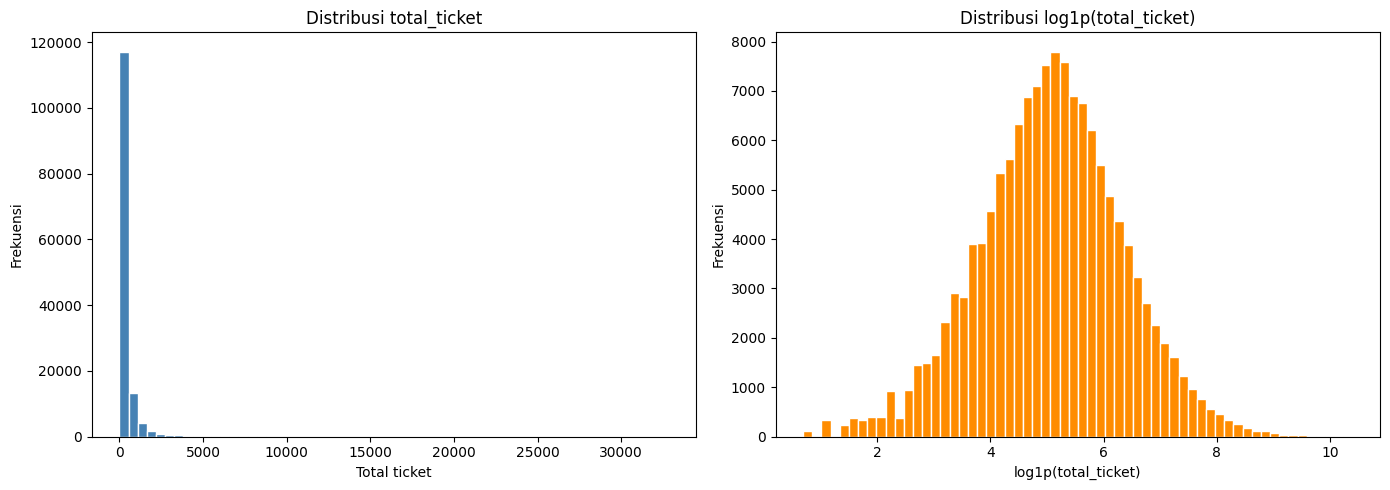

Ringkasan scale_raw:


,scale_raw
count,11823.000000
mean,204.523669
std,554.231694
min,0.333333
25%,24.000000
50%,73.666667
75%,194.333333
max,24117.333333


Pasangan yang benar-benar di-clip oleh max(1, scale): 71 (0.60%)
Pasangan yang berada di floor scale=1: 112 (0.95%)
Lima pasangan dengan scale terkecil:


,movie_title_key,cinema_ids,scale_raw,max_ticket,min_ticket,mean_total_show,mean_occupation_rate,n_obs,d1_date,scale,was_clipped,at_floor
1515,CAUGHT STEALING,df7f047e9886cfa1c0892c97f15d4146,0.333333,1.0,0.0,0.666667,0.343333,3,2025-10-30,1.0,True,True
2329,EPIC: ELVIS PRESLEY IN CONCERT,f3a9ac312f7bc4e2467a1bf02a6aa1e9,0.333333,1.0,0.0,1.666667,0.000000,3,2026-02-28,1.0,True,True
2572,G-DRAGON IN CINEMA: UBERMENSCH,ea7df0c99b450ecdea38cf34ae1f158f,0.333333,1.0,0.0,0.333333,0.000000,3,2025-10-29,1.0,True,True
3648,JUARA SEJATI,4e12b237c826209f7ddc5b29a96380b6,0.333333,1.0,0.0,3.333333,0.000000,3,2026-03-05,1.0,True,True
3651,JUARA SEJATI,52eed153a88a6bdcb46cbb266a07cba2,0.333333,1.0,0.0,1.666667,0.000000,3,2026-03-05,1.0,True,True


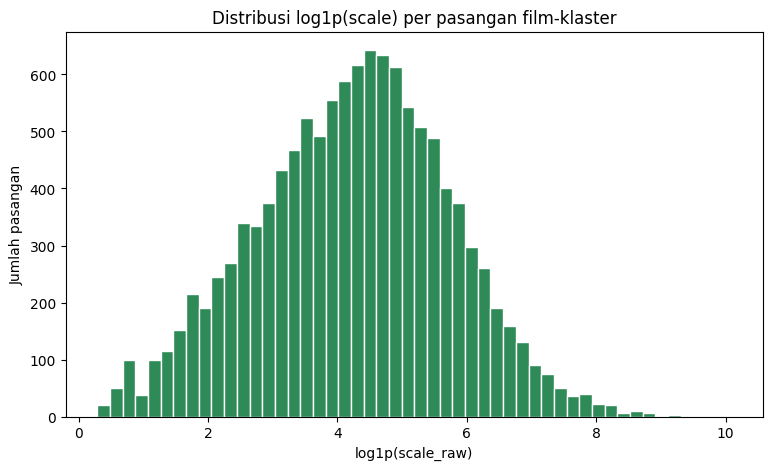

In [54]:
# Distribusi total_ticket dan skala MASE dari tiga hari histori pertama
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train["total_ticket"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribusi total_ticket")
axes[0].set_xlabel("Total ticket")
axes[0].set_ylabel("Frekuensi")
axes[1].hist(np.log1p(train["total_ticket"]), bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("Distribusi log1p(total_ticket)")
axes[1].set_xlabel("log1p(total_ticket)")
axes[1].set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()


def compute_history_stats(history_df, n_days=3, id_cols=("movie_title_key", "cinema_ids")):
    """Aggregate a fixed D1-Dn calendar window for each movie-cluster pair.

    D1 is the earliest date for that pair, not a film-wide calendar date.
    Missing dates inside the window contribute zero ticket/show/occupation.
    """
    history_df = history_df.copy()
    if "movie_title_key" in id_cols and "movie_title_key" not in history_df:
        history_df["movie_title_key"] = history_df["movie_title"]
    id_cols = list(id_cols)
    history_df["date_show"] = pd.to_datetime(history_df["date_show"]).dt.normalize()
    windows = []
    for _, pair in history_df.groupby(id_cols, sort=False, dropna=False):
        pair = pair.sort_values("date_show").drop_duplicates("date_show").set_index("date_show")
        d1 = pair.index.min()
        dates = pd.date_range(d1, periods=n_days, freq="D")
        window = pair.reindex(dates)
        window["date_show"] = dates
        for col in id_cols:
            window[col] = pair[col].iloc[0]
        for col in ("total_ticket", "total_show", "occupation_rate"):
            window[col] = window[col].fillna(0)
        windows.append(window.reset_index(drop=True))
    if not windows:
        return pd.DataFrame(columns=id_cols + ["mean_ticket", "max_ticket", "min_ticket", "mean_total_show", "mean_occupation_rate", "n_obs", "d1_date"])
    window = pd.concat(windows, ignore_index=True)
    stats = window.groupby(id_cols, as_index=False).agg(
        mean_ticket=("total_ticket", "mean"),
        max_ticket=("total_ticket", "max"),
        min_ticket=("total_ticket", "min"),
        mean_total_show=("total_show", "mean"),
        mean_occupation_rate=("occupation_rate", "mean"),
        n_obs=("date_show", "size"),
        d1_date=("date_show", "min"),
    )
    return stats


# hitung_skala: rata-rata D1-D3 per pasangan film-klaster (mengikuti definisi resmi di deskripsi).
scale_table = compute_history_stats(test_history, n_days=3).rename(
    columns={"mean_ticket": "scale_raw"}
)
scale_table["scale"] = scale_table["scale_raw"].clip(lower=1)
scale_table["was_clipped"] = scale_table["scale_raw"] < 1
scale_table["at_floor"] = scale_table["scale_raw"] <= 1

print("Ringkasan scale_raw:")
display(scale_table["scale_raw"].describe().to_frame())
print(f"Pasangan yang benar-benar di-clip oleh max(1, scale): {scale_table['was_clipped'].sum():,} "
      f"({scale_table['was_clipped'].mean() * 100:.2f}%)")
print(f"Pasangan yang berada di floor scale=1: {scale_table['at_floor'].sum():,} "
      f"({scale_table['at_floor'].mean() * 100:.2f}%)")
print("Lima pasangan dengan scale terkecil:")
display(scale_table.nsmallest(5, "scale_raw"))

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(scale_table["scale_raw"]), bins=50, color="seagreen", edgecolor="white")
plt.title("Distribusi log1p(scale) per pasangan film-klaster")
plt.xlabel("log1p(scale_raw)")
plt.ylabel("Jumlah pasangan")
plt.show()


Rata-rata total_ticket berdasarkan tipe hari:


,count,mean,median
day_tipe,,,
weekend,39569,445.993909,209.0
friday,20518,368.409007,168.0
weekday,78872,304.314586,138.0


Rata-rata total_ticket berdasarkan normal vs holiday:


,count,mean,median
holiday_tipe,,,
holiday,8234,556.649259,269.0
normal,130725,341.365454,155.0


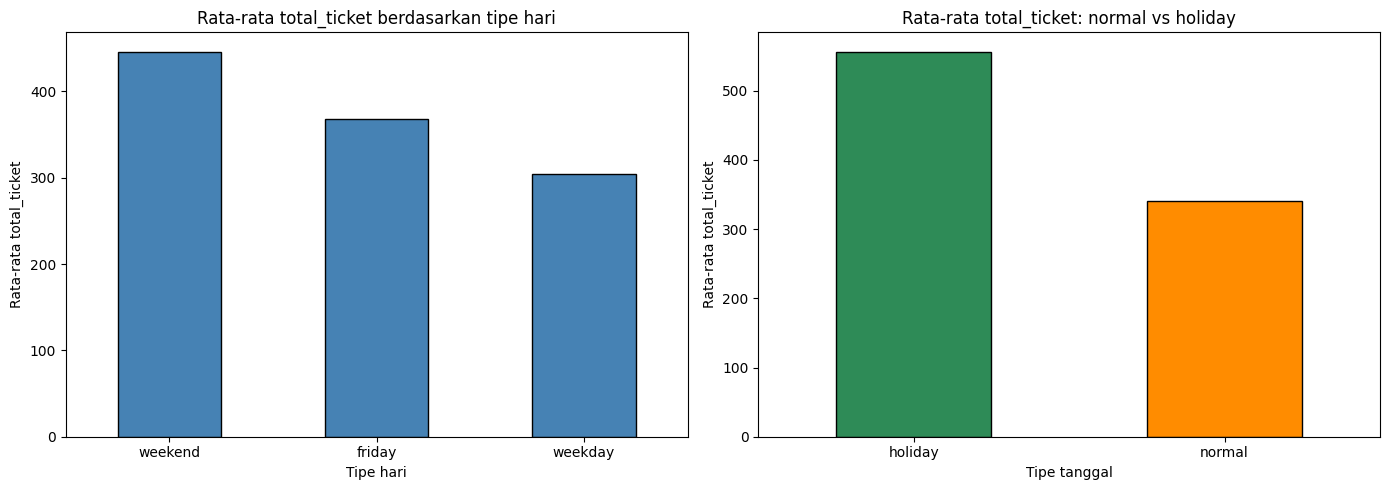

Jumlah hari libur terdeteksi: 18


,date,holiday_name
0,2025-04-01,Idulfitri 1446 H
17,2025-04-18,Wafat Yesus Kristus
19,2025-04-20,Kebangkitan Yesus Kristus (Paskah)
30,2025-05-01,Hari Buruh Internasional
41,2025-05-12,Hari Raya Waisak 2569 BE
58,2025-05-29,Kenaikan Yesus Kristus
61,2025-06-01,Hari Lahir Pancasila
66,2025-06-06,Idul Adha 1446 H
87,2025-06-27,1 Muharam Tahun Baru Islam 1447 H
138,2025-08-17,Proklamasi Kemerdekaan Republik Indonesia


Efek H-1, hari-H, dan H+1 untuk setiap hari libur:


,holiday_date,holiday_name,offset,date_show,mean_total_ticket
0,2025-04-01,Idulfitri 1446 H,-1,2025-03-31,NaN
1,2025-04-01,Idulfitri 1446 H,0,2025-04-01,574.753731
2,2025-04-01,Idulfitri 1446 H,1,2025-04-02,701.327091
3,2025-04-18,Wafat Yesus Kristus,-1,2025-04-17,603.520104
4,2025-04-18,Wafat Yesus Kristus,0,2025-04-18,889.448276
5,2025-04-18,Wafat Yesus Kristus,1,2025-04-19,804.912827
6,2025-04-20,Kebangkitan Yesus Kristus (Paskah),-1,2025-04-19,804.912827
7,2025-04-20,Kebangkitan Yesus Kristus (Paskah),0,2025-04-20,700.045802
8,2025-04-20,Kebangkitan Yesus Kristus (Paskah),1,2025-04-21,430.196005
9,2025-05-01,Hari Buruh Internasional,-1,2025-04-30,472.145205


Rata-rata efek berdasarkan offset (gabungan semua hari libur):


,count,mean,median
offset,,,
-1,10,447.900740,460.590135
0,11,554.027424,574.753731
1,11,466.240460,430.196005


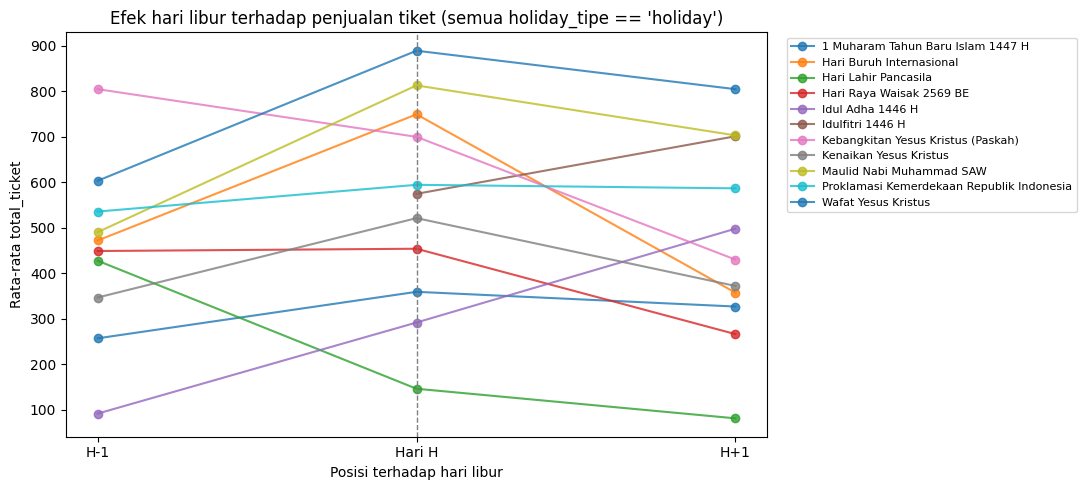

In [55]:
# Dampak hari libur dan efek H-1/H+1
import matplotlib.pyplot as plt

train_holiday = train.merge(
    holidays[["date", "day_tipe", "holiday_tipe", "holiday_name"]],
    left_on="date_show",
    right_on="date",
    how="left",
)

print("Rata-rata total_ticket berdasarkan tipe hari:")
day_summary = (
    train_holiday.groupby("day_tipe", dropna=False)["total_ticket"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(day_summary)

print("Rata-rata total_ticket berdasarkan normal vs holiday:")
holiday_summary = (
    train_holiday.groupby("holiday_tipe", dropna=False)["total_ticket"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(holiday_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
day_summary["mean"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Rata-rata total_ticket berdasarkan tipe hari")
axes[0].set_xlabel("Tipe hari")
axes[0].set_ylabel("Rata-rata total_ticket")
axes[0].tick_params(axis="x", rotation=0)

holiday_summary["mean"].plot(kind="bar", ax=axes[1], color=["seagreen", "darkorange"], edgecolor="black")
axes[1].set_title("Rata-rata total_ticket: normal vs holiday")
axes[1].set_xlabel("Tipe tanggal")
axes[1].set_ylabel("Rata-rata total_ticket")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

major_holidays = (
    holidays.loc[holidays["holiday_tipe"] == "holiday", ["date", "holiday_name"]]
    .drop_duplicates()
    .sort_values("date")
)
print(f"Jumlah hari libur terdeteksi: {len(major_holidays)}")
display(major_holidays)

daily_ticket = train.groupby("date_show", as_index=False)["total_ticket"].mean()

holiday_effect_rows = []
for _, event in major_holidays.iterrows():
    for offset in [-1, 0, 1]:
        event_date = event["date"] + pd.Timedelta(days=offset)
        matching = daily_ticket.loc[daily_ticket["date_show"] == event_date, "total_ticket"]
        holiday_effect_rows.append({
            "holiday_date": event["date"],
            "holiday_name": event["holiday_name"],
            "offset": offset,
            "date_show": event_date,
            "mean_total_ticket": matching.iloc[0] if len(matching) else np.nan,
        })

holiday_effect = pd.DataFrame(holiday_effect_rows)
print("Efek H-1, hari-H, dan H+1 untuk setiap hari libur:")
display(holiday_effect)
print("Rata-rata efek berdasarkan offset (gabungan semua hari libur):")
offset_summary = holiday_effect.groupby("offset")["mean_total_ticket"].agg(["count", "mean", "median"])
display(offset_summary)

# Catatan: banyak tanggal libur (holidays.csv sampai Apr 2026) berada di luar
# rentang train.csv (Apr-Sep 2025), jadi mean_total_ticket-nya otomatis NaN.
# Baris NaN itu wajar dan diabaikan saat plotting di bawah.
plt.figure(figsize=(11, 5))
for holiday_name, event_data in holiday_effect.groupby("holiday_name"):
    event_data = event_data.sort_values("offset")
    if event_data["mean_total_ticket"].isna().all():
        continue
    plt.plot(
        event_data["offset"],
        event_data["mean_total_ticket"],
        marker="o",
        linewidth=1.5,
        alpha=0.8,
        label=holiday_name,
    )
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xticks([-1, 0, 1], ["H-1", "Hari H", "H+1"])
plt.xlabel("Posisi terhadap hari libur")
plt.ylabel("Rata-rata total_ticket")
plt.title("Efek hari libur terhadap penjualan tiket (semua holiday_tipe == \'holiday\')")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
plt.tight_layout()
plt.show()


Distribusi skala klaster berdasarkan histori:


,count,mean,std,min,25%,50%,75%,max
mean_total_ticket,117.0,283.609691,183.045367,32.253061,174.354515,249.129239,342.679821,1422.579413
median_total_ticket,117.0,156.495726,65.572528,26.000000,117.000000,150.000000,192.000000,475.000000
mean_occupation_rate,117.0,29.177938,6.775113,14.435788,24.719357,28.357617,32.797396,63.789735
mean_total_show,117.0,6.178970,3.988652,2.877551,3.934227,4.790909,6.886792,30.206226
observations,117.0,1187.683761,549.198423,212.000000,821.000000,1123.000000,1477.000000,2899.000000


Klaster terbesar dan terkecil:


,mean_total_ticket,median_total_ticket,mean_occupation_rate,mean_total_show,observations
cinema_ids,,,,,
8dbfb7aeb4ed822b358347332ba630af,1422.579413,475.0,26.658348,30.206226,2827
4ed104ac0de10ba7eef50158603e0b32,901.404967,289.0,25.654115,23.276647,2899
108f9a4d181f12fd1b7e3c9adae38478,710.366332,276.0,21.988556,17.371566,2293
c4a19cbeb409639c836e4304976db0aa,696.665146,294.0,26.897217,14.106752,2192
0191582d75f94a412c0fa12d36bcee3f,615.950680,267.0,29.751705,10.678447,2575
5b8eaa351fae8e6d1e759e814d74c1c5,553.021086,246.0,28.592699,12.592514,1897
a9e141baa8b4ec825325397b16eeaae3,530.955273,201.0,24.044815,11.414136,1811
b704e8b10f13e14494b5a7a0ba39d9d9,530.001089,227.5,26.220508,14.994194,2756
015555fbcd8faef6b55a854605df0a87,527.256483,222.0,23.388100,12.291995,1774


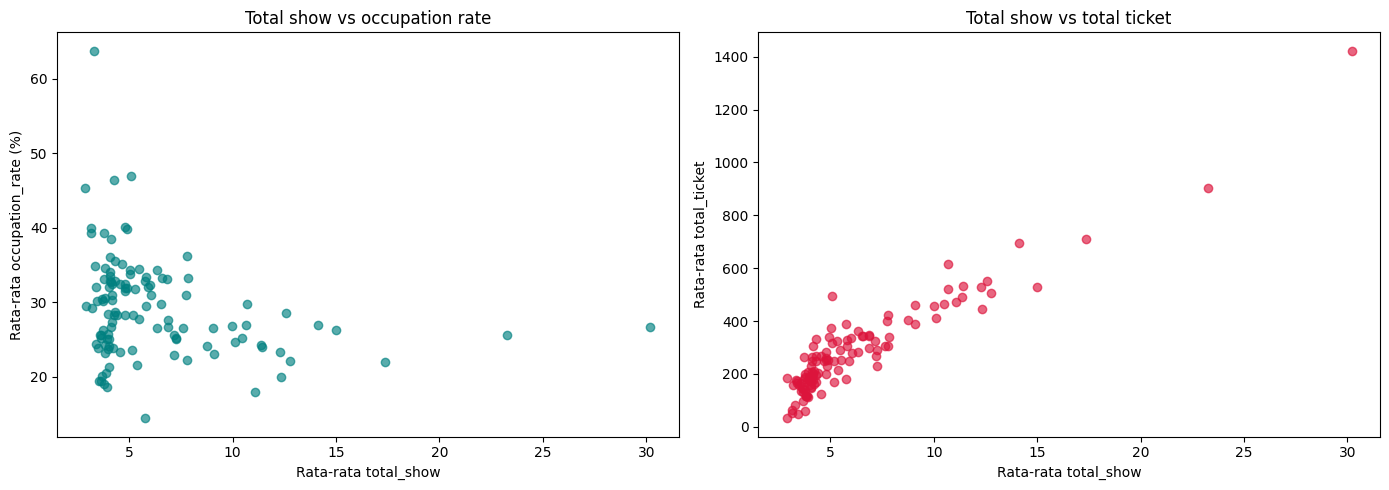

Estimasi kapasitas kursi per show per klaster:


,count,median,mean,min,max
count,117.000000,117.000000,117.000000,117.000000,117.000000
mean,1185.658120,147.792980,159.735394,88.235347,3062.495597
std,548.487657,34.032222,37.657587,47.474322,3096.475350
min,212.000000,24.247492,24.778618,21.346470,52.380952
25%,821.000000,134.594088,146.413493,38.834951,1142.857143
50%,1121.000000,148.222767,161.634757,103.174603,2000.000000
75%,1473.000000,164.587699,182.711732,126.026460,3523.809524
max,2897.000000,214.965986,227.336479,205.513784,15576.923077


,count,median,mean,min,max
cinema_ids,,,,,
26d1d720bc7e60c1b1a56630e3ba2c5d,651,214.965986,216.968888,151.098901,1396.103896
b2539b1f80254243391774489b1328aa,569,214.811477,227.336479,205.513784,6548.387097
c35e24eefa840ac2009279f1efc52288,820,214.457365,206.766815,126.984127,1142.857143
4ba87a86e02dd8a810032db35bf13c51,829,201.201201,164.418523,66.666667,1285.714286
45f553cca86b28fedd6115abdd0ae734,683,201.159626,212.304850,188.261351,5190.476190
afbb3b11f728a54ad1eb3ca34f602779,871,199.611462,223.182754,174.757282,5904.761905
3c41b96b56b0aab1ed5fc5e703499730,1268,193.423169,193.040468,23.296447,3000.000000
592095e0ddc2c230cf3002d72e9bac41,856,190.392184,193.063926,158.730159,1523.809524
716ede53fbca27fbe1c1a55d6667c2b5,1431,189.995190,220.814724,114.285714,1153.846154


In [56]:
# Perbandingan karakter antar cinema cluster
cluster_summary = (
    train.groupby("cinema_ids")
    .agg(
        mean_total_ticket=("total_ticket", "mean"),
        median_total_ticket=("total_ticket", "median"),
        mean_occupation_rate=("occupation_rate", "mean"),
        mean_total_show=("total_show", "mean"),
        observations=("total_ticket", "size"),
    )
    .sort_values("mean_total_ticket", ascending=False)
)
print("Distribusi skala klaster berdasarkan histori:")
display(cluster_summary.describe().T)
print("Klaster terbesar dan terkecil:")
display(pd.concat([cluster_summary.head(10), cluster_summary.tail(10)]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    cluster_summary["mean_total_show"],
    cluster_summary["mean_occupation_rate"],
    alpha=0.65,
    color="teal",
)
axes[0].set_title("Total show vs occupation rate")
axes[0].set_xlabel("Rata-rata total_show")
axes[0].set_ylabel("Rata-rata occupation_rate (%)")
axes[1].scatter(
    cluster_summary["mean_total_show"],
    cluster_summary["mean_total_ticket"],
    alpha=0.65,
    color="crimson",
)
axes[1].set_title("Total show vs total ticket")
axes[1].set_xlabel("Rata-rata total_show")
axes[1].set_ylabel("Rata-rata total_ticket")
plt.tight_layout()
plt.show()

# Reverse-engineer estimasi kapasitas kursi per show.
train["estimated_capacity_per_show"] = np.where(
    (train["total_show"] > 0) & (train["occupation_rate"] > 0),
    train["total_ticket"] / (train["total_show"] * train["occupation_rate"] / 100),
    np.nan,
)
capacity_by_cluster = (
    train.groupby("cinema_ids")["estimated_capacity_per_show"]
    .agg(["count", "median", "mean", "min", "max"])
    .sort_values("median", ascending=False)
)
print("Estimasi kapasitas kursi per show per klaster:")
display(capacity_by_cluster.describe())
display(capacity_by_cluster.head(10))

Baris tanpa harga kota-hari yang cocok: 277918
Jumlah baris asli (train): 138959 | setelah join & filter: 138959
Ringkasan harga tiket vs permintaan per kota:


,mean_price,mean_total_ticket,median_total_ticket,mean_occupation_rate,observations
city_name,,,,,
PALU,60753.935377,248.382767,151.0,35.212088,1207
BANJARMASIN,58653.061224,299.522449,190.0,39.892105,1715
GORONTALO,54312.333629,169.333629,116.0,28.337853,1127
MAKASSAR,53600.048864,364.851698,210.0,33.486540,4093
PONTIANAK,52991.228070,493.217544,329.5,46.977588,1140
...,...,...,...,...,...
PEKANBARU,33556.505223,265.881925,144.0,30.106682,3159
MAMUJU,33379.120879,165.142857,117.0,24.370316,728
BONDOWOSO,24395.448080,158.886202,117.0,23.846387,703


Korelasi harga rata-rata dengan permintaan kota:


,mean_price,mean_total_ticket,median_total_ticket,mean_occupation_rate,observations
mean_price,1.000000,0.281502,0.382500,0.469101,0.178072
mean_total_ticket,0.281502,1.000000,0.880131,0.134672,0.844175
median_total_ticket,0.382500,0.880131,1.000000,0.457712,0.617350
mean_occupation_rate,0.469101,0.134672,0.457712,1.000000,-0.060007
observations,0.178072,0.844175,0.617350,-0.060007,1.000000


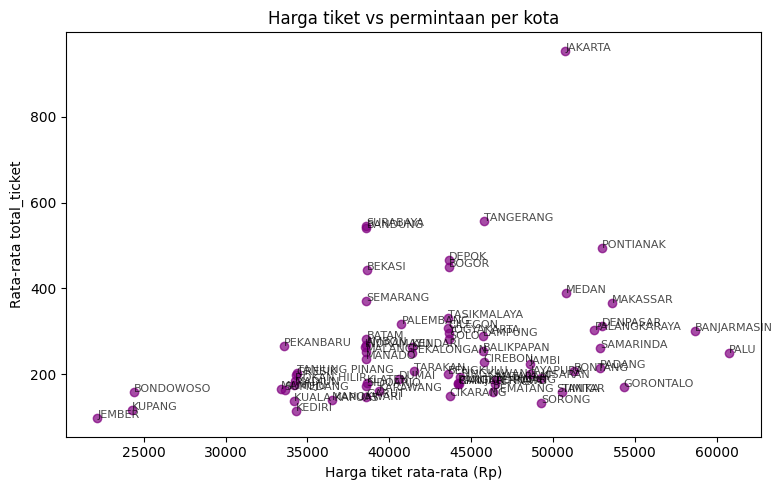

In [57]:
# Join harga tiket berdasarkan kota dan tipe hari
# 1. Join train dengan holidays untuk dapat day_tipe
train_h = train.merge(
    holidays.rename(columns={"date": "date_show"}),
    on="date_show",
    how="left",
)

# 2. Baru join dengan ticket_prices. Ini many-to-many by city_name karena tiap
#    kota punya 3 baris harga (Weekday/Friday/Weekend), makanya difilter oleh
#    price_day_normalized di bawah sebelum groupby, supaya tidak ada duplikasi baris.
train_prices = train_h.merge(
    ticket_prices,
    on="city_name",
    how="left",
    suffixes=("", "_price"),
)

train_prices["price_day_normalized"] = train_prices["day_tipe"].map({
    "weekday": "Weekday",
    "friday": "Friday",
    "weekend": "Weekend",
})

train_prices["city_day_price"] = np.where(
    train_prices["price_day"] == train_prices["price_day_normalized"],
    train_prices["ceil"],
    np.nan,
)

print("Baris tanpa harga kota-hari yang cocok:", train_prices["city_day_price"].isna().sum())

# Hapus baris duplikat hasil merge many-to-many, sisakan 1 baris harga per observasi asli
train_prices_clean = train_prices.dropna(subset=["city_day_price"])
print("Jumlah baris asli (train):", len(train), "| setelah join & filter:", len(train_prices_clean))

city_price_demand = (
    train_prices_clean.groupby("city_name")
    .agg(
        mean_price=("city_day_price", "mean"),
        mean_total_ticket=("total_ticket", "mean"),
        median_total_ticket=("total_ticket", "median"),
        mean_occupation_rate=("occupation_rate", "mean"),
        observations=("total_ticket", "size"),
    )
    .dropna()
)

print("Ringkasan harga tiket vs permintaan per kota:")
display(city_price_demand.sort_values("mean_price", ascending=False))

print("Korelasi harga rata-rata dengan permintaan kota:")
display(city_price_demand.corr(numeric_only=True))

plt.figure(figsize=(8, 5))
plt.scatter(
    city_price_demand["mean_price"],
    city_price_demand["mean_total_ticket"],
    alpha=0.7,
    color="purple",
)
for city, row in city_price_demand.iterrows():
    plt.annotate(city, (row["mean_price"], row["mean_total_ticket"]), fontsize=8, alpha=0.7)
plt.xlabel("Harga tiket rata-rata (Rp)")
plt.ylabel("Rata-rata total_ticket")
plt.title("Harga tiket vs permintaan per kota")
plt.tight_layout()
plt.show()


In [58]:
# Analisis genre, decay historis, dan normalisasi title format
movie_lookup = movies[["original_title", "genre"]].drop_duplicates("original_title").copy()
movie_lookup["movie_title_norm"] = normalize_title(movie_lookup["original_title"])
train["movie_title_key"] = train["movie_title"]
train["movie_title_norm"] = normalize_title(train["movie_title"])
train_movies = train.merge(
    movie_lookup[["movie_title_norm", "genre"]].drop_duplicates("movie_title_norm"),
    on="movie_title_norm",
    how="left",
)
train_movies["date_rank"] = train_movies.groupby(
    ["movie_title_key", "cinema_ids"]
)["date_show"].rank(method="dense", ascending=True)

# Bandingkan D1 dengan hari-hari berikutnya untuk pasangan yang punya histori cukup.
pair_first_last = (
    train_movies[train_movies["date_rank"] <= 7]
    .groupby(["movie_title_key", "cinema_ids", "genre", "date_rank"], dropna=False)["total_ticket"]
    .mean()
    .reset_index()
)
pair_decay = pair_first_last.pivot_table(
    index=["movie_title_key", "cinema_ids", "genre"],
    columns="date_rank",
    values="total_ticket",
)
pair_decay["decay_d7_vs_d1"] = pair_decay.get(7, np.nan) / pair_decay.get(1, np.nan)
print("Decay median berdasarkan genre (nilai < 1 berarti turun):")
display(
    pair_decay.reset_index()
    .groupby("genre", dropna=False)["decay_d7_vs_d1"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
    .head(30)
)

format_pattern = r"2D|3D|IMAX|DUBBING"
test["has_format_marker"] = test["movie_title"].str.contains(
    format_pattern, case=False, regex=True, na=False
)
format_titles = test.loc[test["has_format_marker"], "movie_title"].drop_duplicates().sort_values()
print(f"Jumlah title test dengan penanda format: {len(format_titles)}")
display(format_titles.to_frame("movie_title").head(50))
print("Jumlah title katalog yang menjadi duplikat setelah normalisasi format:")
movie_normalized = normalize_title(movies["original_title"])
normalized_duplicates = movies.assign(normalized_title=movie_normalized).groupby(
    "normalized_title"
)["original_title"].nunique()
display(normalized_duplicates[normalized_duplicates > 1].sort_values(ascending=False).head(30).to_frame("jumlah_title"))

Decay median berdasarkan genre (nilai < 1 berarti turun):


,count,median,mean
genre,,,
Romance,1,3.857143,3.857143
"Animation, Fantasy, Drama",115,3.046316,3.104064
"Action, Adventure",103,2.800000,7.203094
"Horror, Thriller",160,1.620811,2.980988
"Horror, Thriller, Mystery",123,1.427536,1.775619
Drama,922,1.407515,2.079236
"Drama, Thriller",108,1.139189,1.462701
Action,289,1.087500,1.467404
"Crime, Action",113,1.034483,1.209618


Jumlah title test dengan penanda format: 20


,movie_title
6237,AVATAR: FIRE AND ASH (3D)
6370,AVATAR: FIRE AND ASH (IMAX 3D)
8582,BLADES OF THE GUARDIANS (IMAX 2D)
11466,DANUR: THE LAST CHAPTER (IMAX 2D)
13979,EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)
19047,HOPPERS (3D)
19110,HOPPERS (IMAX 2D)
28140,MERCY (IMAX 2D)
39697,PREDATOR: BADLANDS (3D)
39711,PREDATOR: BADLANDS (IMAX 2D)


Jumlah title katalog yang menjadi duplikat setelah normalisasi format:


,jumlah_title
normalized_title,


In [59]:
# Pemeriksaan representasi ekstrem dan inkonsistensi numerik
# FIX: cell ini sebelumnya menghitung ulang D1-D3 dengan logika terpisah dari cell
# scale/MASE di atas (duplikasi). Sekarang pakai ulang compute_history_stats()
# yang sudah didefinisikan sebelumnya, supaya D1-D3 hanya dihitung dengan satu
# definisi yang konsisten di seluruh notebook.
pair_d1_d3 = compute_history_stats(test_history, n_days=3).rename(
    columns={"mean_ticket": "mean_d1_d3", "max_ticket": "max_d1_d3"}
)

print("Pasangan dengan D1-D3 tertinggi:")
display(pair_d1_d3.sort_values("mean_d1_d3", ascending=False).head(20))
print("Pasangan dengan D1-D3 terendah:")
display(pair_d1_d3.sort_values("mean_d1_d3", ascending=True).head(20))

zero_show_positive_ticket = train[(train["total_show"] == 0) & (train["total_ticket"] > 0)]
positive_show_zero_ticket = train[(train["total_show"] > 0) & (train["total_ticket"] == 0)]
print("\nAnomali total_show=0 tetapi total_ticket>0:", len(zero_show_positive_ticket))
print("Anomali total_show>0 tetapi total_ticket=0:", len(positive_show_zero_ticket))

invalid_occupation = train[
    (train["occupation_rate"] < 0) | (train["occupation_rate"] > 100)
]
print("occupation_rate di luar rentang 0-100:", len(invalid_occupation))
print("Ringkasan nilai ekstrem total_ticket:")
display(train["total_ticket"].describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())


Pasangan dengan D1-D3 tertinggi:


,movie_title_key,cinema_ids,mean_d1_d3,max_d1_d3,min_ticket,mean_total_show,mean_occupation_rate,n_obs,d1_date
275,AGAK LAEN: MENYALA PANTIKU!,8dbfb7aeb4ed822b358347332ba630af,24117.333333,37989.0,13860.0,208.666667,58.516667,3,2025-11-27
249,AGAK LAEN: MENYALA PANTIKU!,4ed104ac0de10ba7eef50158603e0b32,18399.000000,27676.0,12460.0,169.666667,58.433333,3,2025-11-27
960,AVATAR: FIRE AND ASH,8dbfb7aeb4ed822b358347332ba630af,15887.000000,19068.0,14296.0,179.666667,52.250000,3,2025-12-17
219,AGAK LAEN: MENYALA PANTIKU!,108f9a4d181f12fd1b7e3c9adae38478,10179.666667,17411.0,5219.0,88.666667,55.403333,3,2025-11-27
934,AVATAR: FIRE AND ASH,4ed104ac0de10ba7eef50158603e0b32,9652.333333,10610.0,8885.0,141.333333,45.270000,3,2025-12-17
297,AGAK LAEN: MENYALA PANTIKU!,b704e8b10f13e14494b5a7a0ba39d9d9,9102.333333,13393.0,5686.0,102.000000,52.973333,3,2025-11-27
296,AGAK LAEN: MENYALA PANTIKU!,b4972b48997defae8304bc9c41220c7c,8046.000000,14175.0,4083.0,63.666667,55.203333,3,2025-11-27
674,ALAS ROBAN,8dbfb7aeb4ed822b358347332ba630af,7332.666667,7856.0,6876.0,93.000000,37.876667,3,2026-01-15
213,AGAK LAEN: MENYALA PANTIKU!,0191582d75f94a412c0fa12d36bcee3f,6947.000000,9922.0,4915.0,61.666667,53.733333,3,2025-11-27
897,AVATAR: FIRE AND ASH,0191582d75f94a412c0fa12d36bcee3f,6494.333333,7270.0,5652.0,54.000000,65.473333,3,2025-12-17


Pasangan dengan D1-D3 terendah:


,movie_title_key,cinema_ids,mean_d1_d3,max_d1_d3,min_ticket,mean_total_show,mean_occupation_rate,n_obs,d1_date
5465,NUMBER ONE,fbaf4d5f0c18dc603a21aef31da59ee6,0.333333,1.0,0.0,0.333333,0.000000,3,2026-03-13
4443,MARIA,f54d37fc4c4d4b285aa3601041abc938,0.333333,1.0,0.0,2.333333,0.100000,3,2025-10-04
9187,THE BRIDE!,ef2896a95abe2a2b4cfee245dc1e36ec,0.333333,1.0,0.0,1.333333,0.000000,3,2026-03-04
8571,SOSOK KETIGA: LINTRIK,c71a18e33d4b7c73c8124c65fc3e6f1c,0.333333,1.0,0.0,1.000000,0.000000,3,2025-11-06
3664,JUARA SEJATI,a09b9ee7f937939ee25c24ef8c2e91be,0.333333,1.0,0.0,1.666667,0.000000,3,2026-03-05
3668,JUARA SEJATI,b4972b48997defae8304bc9c41220c7c,0.333333,1.0,0.0,1.666667,0.000000,3,2026-03-05
11140,"WE, EVERYDAY",4fc3fc370b299876663c7d5c90595853,0.333333,1.0,0.0,0.666667,0.000000,3,2026-03-11
4405,MARIA,3afae5dea7356f64f70605334bef46a7,0.333333,1.0,0.0,0.666667,0.000000,3,2025-10-04
5426,NUMBER ONE,9aab42397bbc1d1cdb49f7044dc990f0,0.333333,1.0,0.0,1.000000,0.000000,3,2026-03-11
2329,EPIC: ELVIS PRESLEY IN CONCERT,f3a9ac312f7bc4e2467a1bf02a6aa1e9,0.333333,1.0,0.0,1.666667,0.000000,3,2026-02-28



Anomali total_show=0 tetapi total_ticket>0: 0
Anomali total_show>0 tetapi total_ticket=0: 0
occupation_rate di luar rentang 0-100: 0
Ringkasan nilai ekstrem total_ticket:


,total_ticket
count,138959.000000
mean,354.122072
std,725.927987
min,1.000000
1%,5.000000
5%,18.000000
50%,161.000000
95%,1264.000000
99%,3136.420000
max,32845.000000


## 4. Feature engineering, modeling, dan evaluation

Kode pipeline lengkap ada di sel berikutnya: pengambilan metadata TMDB opsional, penggabungan katalog, fitur D1-D3 dan kalender, tabel fitur, holdout temporal, baseline MASE, serta LightGBM L1. Default Run All memakai metadata lokal yang sudah diunduh dan tidak memanggil API. Fungsi `compute_history_stats()` dari notebook ini dipakai langsung.

Skor MASE merupakan validasi lokal pada `train.csv`, bukan skor submission/Kaggle.

### Asumsi holiday tier untuk baseline

Hari biasa memakai multiplier 1, `minor_multiplier` dikalibrasi pada holdout temporal, dan `major_multiplier` hanya diterapkan pada jendela tanggal Idulfitri serta Natal/Tahun Baru yang ditetapkan di kode. Holdout validasi tidak berisi jendela major, jadi MASE lokal tidak dapat memilih `major_multiplier`. Jendela Idulfitri 1446 H hanya memberi sinyal ekor: train mencakup 2.454 baris pada 2?4 April 2025, tetapi hanya 794 baris pada 4 April yang memiliki tiga observasi terdahulu; observasi terdahulu itu sendiri sudah berada di jendela major dan bukan pembanding non-event. Karena itu sinyal ini lemah dan bukan kalibrasi solid. `major_multiplier=1.6` merupakan asumsi domain untuk event besar yang belum punya preseden bersih di data; hasilnya tidak boleh disebut hasil tuning penuh. Multiplier minor dipilih terpisah dari holdout.


test title collisions: normalized groups=228, affected rows=3388, raw identity collisions=0
train title collisions: normalized groups=305, affected rows=10307, raw identity collisions=0
Test collision normalized titles absent from train: 15
Affected test normalized titles: ['AVATAR FIRE AND ASH', 'BLADES OF THE GUARDIANS', 'DANUR THE LAST CHAPTER', 'EPIC ELVIS PRESLEY IN CONCERT', 'HOPPERS', 'MERCY', 'PREDATOR BADLANDS', 'SCREAM 7', 'STRAY KIDS THE DOMINATE EXPERIENCE', 'THE BRIDE', 'THE RUNNING MAN', 'TRON ARES', 'WICKED FOR GOOD', 'WUTHERING HEIGHTS', 'ZOOTOPIA 2']
Feature rows: 72,611; titles missing genre/rating: 0/0
Unmapped external age ratings: []
Identity-key collision count on test (expected 0): 0
Scale=1 audit: 41 raw identity pairs; exact-key overlap=3; normalized metadata-key overlap=4; ID dtypes=str/str
Genre decay profile learned from pre-holdout 3+7 windows:


genre,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Musical,Mystery,Religi,Romance,Sci-Fi,Sport,Superhero,Thriller,War
days_since_d1,,,,,,,,,,,,,,,,,,,,
4,0.9408,1.5983,1.0766,0.9051,1.7734,0.0,1.0432,1.7851,1.5951,0.9069,1.0941,1.8043,1.2353,0.1765,0.8968,1.2780,1.2593,1.2241,1.0002,0.9310
5,1.6255,1.6076,0.9414,1.1287,1.9090,0.0,1.9947,0.6967,1.6435,1.0463,1.2703,0.0000,1.0906,0.4333,0.5135,1.1694,1.0607,1.0144,1.1905,0.8639
6,1.2315,1.2755,0.9653,1.4405,1.5216,0.0,2.1002,1.6672,1.2711,1.0685,2.2652,0.0000,2.2392,0.5417,1.7972,0.7941,0.8443,0.5648,1.8283,0.8303
7,1.2349,1.3082,1.0660,1.4465,1.4802,0.0,2.1994,2.0807,1.5080,0.6628,2.3170,0.0000,2.0409,0.3810,0.8735,0.6847,0.7454,0.4332,1.7032,1.0422
8,1.5616,1.2716,1.1890,1.5457,1.6153,0.0,2.5493,2.0755,1.4000,0.6023,2.3082,0.0430,2.1602,0.3580,1.4552,0.5504,0.5580,0.3737,1.5958,1.3370
9,1.6478,1.6974,1.0893,1.3123,2.1781,0.0,2.3558,1.6246,1.5076,0.6036,2.6853,0.0129,2.6802,0.2227,1.0402,0.4994,0.4707,0.3327,2.3842,1.5836
10,1.1921,1.6810,1.0141,1.4026,2.1071,0.0,2.1716,2.2512,1.5544,0.3851,2.3094,0.0441,1.9008,1.0161,0.9046,0.4375,0.4584,0.3222,2.0621,1.6372


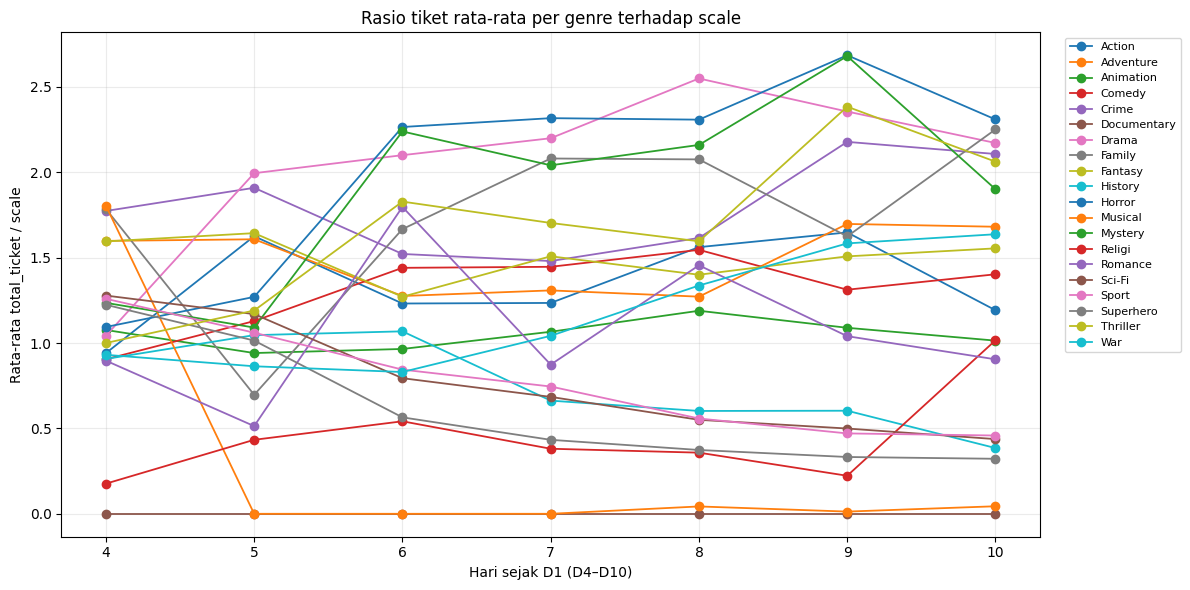

Old generic-decay MASE, all / scale>1: 5.912470000301137 0.600853167394349
Genre-decay baseline MASE, all / scale>1: 6.766415554006442 1.5301003805485227
Previous single holiday multiplier (1.63) MASE, generic decay: 5.925910792574984
Holiday multiplier grid MASE: {'minor_multiplier': 1.0, 'major_multiplier': 1.3} 6.76678470350744
Holiday multiplier grid MASE: {'minor_multiplier': 1.0, 'major_multiplier': 1.6} 6.767160875754882
Holiday multiplier grid MASE: {'minor_multiplier': 1.0, 'major_multiplier': 2.0} 6.767662438751469
Holiday multiplier grid MASE: {'minor_multiplier': 1.0, 'major_multiplier': 2.5} 6.768289392497205
Holiday multiplier grid MASE: {'minor_multiplier': 1.0, 'major_multiplier': 3.0} 6.768916346242937
Holiday multiplier grid MASE: {'minor_multiplier': 1.1, 'major_multiplier': 1.3} 6.774074854811641
Holiday multiplier grid MASE: {'minor_multiplier': 1.1, 'major_multiplier': 1.6} 6.774451027059082
Holiday multiplier grid MASE: {'minor_multiplier': 1.1, 'major_multiplier

,id,total_ticket
0,1,41.768484
1,2,44.564170
2,3,44.564170
3,4,42.538404
4,5,51.946122


Representative MASE (scale>1), baseline genre-decay / LightGBM p99-clipped: 1.5301003805485227 0.6543392681416778


In [60]:
"""Feature, temporal validation, baseline and L1 boosting pipeline.

Usage: python scripts/build_pipeline.py [--fetch-metadata]
Fetching requires TMDB_READ_ACCESS_TOKEN (or TMDB_API_KEY).
"""
from __future__ import annotations
import os, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "dataset").is_dir():
    raise FileNotFoundError(
        "Run this notebook with the project folder as the working directory"
    )
DATA = ROOT / "dataset"
OUT = ROOT / "data"
EXT = ROOT / "external_data"
SEED = 2026
MAJOR_HOLIDAY_WINDOWS = [
    ("2025-03-29", "2025-04-04"),  # Idulfitri 1446 H
    ("2025-12-24", "2026-01-02"),  # Natal & Tahun Baru
    ("2026-03-18", "2026-03-25"),  # Idulfitri 1447 H
]
MINOR_MULTIPLIER_GRID = [1.0, 1.1, 1.2, 1.3]
MAJOR_MULTIPLIER_GRID = [1.3, 1.6, 2.0, 2.5, 3.0]
MAJOR_MULTIPLIER_ASSUMPTION = 1.6


def normalize_title_values(values):
    """Apply the same format-marker and punctuation normalization as the EDA cell."""
    titles = (
        values.astype("string").copy()
        if isinstance(values, pd.Series)
        else pd.Series(values, dtype="string")
    )
    return (
        titles.str.upper()
        .str.replace(r"\(\s*(2D|3D|IMAX|DUBBING)\s*\)", "", regex=True)
        .str.replace(r"\b(2D|3D|IMAX|DUBBING)\b", "", regex=True)
        .str.replace(r"[^A-Z0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def normalize_title(value):
    return normalize_title_values([value]).iloc[0]


OFFICIAL_AGE_RATINGS = {"Semua Umur", "Remaja", "Dewasa", "Dewasa 21"}
TMDB_AGE_RATING_MAP = {
    "SU": "Semua Umur",
    "13+": "Remaja",
    "17+": "Dewasa",
    "21+": "Dewasa 21",
}


def map_age_rating(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value in TMDB_AGE_RATING_MAP:
        return TMDB_AGE_RATING_MAP[value]
    return value if value in OFFICIAL_AGE_RATINGS else np.nan


def normalized_genres(series):
    return (
        series.astype("string")
        .str.replace(r"\s*,\s*", "|", regex=True)
        .str.replace(r"\bScience Fiction\b", "Sci-Fi", case=False, regex=True)
    )


def genre_vocabulary():
    genres = normalized_genres(load_movie_metadata().genre).dropna().astype(str)
    return sorted(
        {
            token.strip()
            for value in genres
            for token in value.split("|")
            if token.strip()
        }
    )


def add_genre_flags(frame, genre_vocab):
    out = frame.copy()
    genre_tokens = out["genre"].fillna("").astype(str).str.split("|")
    for token in genre_vocab:
        col = "genre__" + re.sub(r"[^A-Za-z0-9]+", "_", token).strip("_").lower()
        out[col] = genre_tokens.map(lambda values: int(token in values)).astype("int8")
    return out


def assign_holiday_tier(holidays):
    calendar = holidays.copy()
    calendar["date"] = pd.to_datetime(calendar["date"])
    calendar["holiday_tier"] = "normal"
    for start, end in MAJOR_HOLIDAY_WINDOWS:
        calendar.loc[calendar.date.between(start, end, inclusive="both"), "holiday_tier"] = "major"
    is_minor = calendar.holiday_tipe.eq("holiday") & calendar.holiday_tier.ne("major")
    calendar.loc[is_minor, "holiday_tier"] = "minor"
    return calendar


def holiday_adjustment(frame, minor_multiplier, major_multiplier):
    tiers = frame["holiday_tier"].fillna("normal").astype(str)
    return np.select(
        [tiers.eq("minor"), tiers.eq("major")],
        [minor_multiplier, major_multiplier],
        default=1.0,
    )


def add_calendar_features(frame, holidays):
    out = frame.copy()
    holiday_calendar = holidays.rename(columns={"date": "date_show"})
    out = out.merge(
        holiday_calendar[["date_show", "day_tipe", "holiday_tipe", "holiday_name", "holiday_tier"]],
        on="date_show",
        how="left",
        suffixes=("", "_calendar"),
    )
    if "day_tipe_calendar" in out:
        out["day_tipe"] = out["day_tipe"].fillna(out["day_tipe_calendar"])
        out = out.drop(columns="day_tipe_calendar")
    out["day_tipe"] = out["day_tipe"].fillna(
        out.date_show.dt.dayofweek.map(
            lambda d: "weekend" if d >= 5 else ("friday" if d == 4 else "weekday")
        )
    )
    if "holiday_tipe_calendar" in out:
        out["holiday_tipe"] = out["holiday_tipe"].fillna(out["holiday_tipe_calendar"])
        out = out.drop(columns="holiday_tipe_calendar")
    out["holiday_tipe"] = out["holiday_tipe"].fillna("normal")
    out["holiday_tier"] = out["holiday_tier"].fillna("normal")
    dates = out.date_show.values.astype("datetime64[ns]")
    holiday_dates = (
        holidays.loc[holidays.holiday_tipe.eq("holiday"), "date"]
        .dropna()
        .values.astype("datetime64[ns]")
    )
    if len(holiday_dates):
        delta = (
            (dates[:, None] - holiday_dates[None, :])
            .astype("timedelta64[D]")
            .astype(int)
        )
        nearest = np.abs(delta).argmin(axis=1)
        out["days_to_holiday"] = delta[np.arange(len(delta)), nearest]
    else:
        out["days_to_holiday"] = 999
    return out


def load(name):
    return pd.read_csv(DATA / f"{name}.csv")


def fetch_metadata():
    import requests

    def safe_get(url, **kwargs):
        try:
            response = requests.get(url, **kwargs)
            response.raise_for_status()
            return response
        except requests.RequestException as exc:
            status = getattr(getattr(exc, "response", None), "status_code", None)
            raise RuntimeError(
                f"TMDB HTTP request failed (status={status or 'unavailable'}); credential value omitted"
            ) from None

    token = os.getenv("TMDB_API_RAT")
    key = os.getenv("TMDB_API_KEY")
    envfile = ROOT / ".env"
    if (not token or not key) and envfile.exists():
        for line in envfile.read_text(encoding="utf-8").splitlines():
            if "=" not in line or line.lstrip().startswith("#"):
                continue
            name, value = line.split("=", 1)
            name = name.strip().upper()
            value = value.strip().strip("\"'")
            if name == "TMDB_API_RAT" and not token:
                token = value
            if name == "TMDB_API_KEY" and not key:
                key = value
    if not token and not key:
        raise RuntimeError(
            "Set TMDB_API_RAT or TMDB_API_KEY in environment or project .env"
        )
    test = load("test")
    catalog = load("movies")
    missing = sorted(
        set(normalize_title_values(test.movie_title.dropna()))
        - set(normalize_title_values(catalog.original_title.dropna()))
    )
    rows = []
    audit = []
    headers = {"Authorization": f"Bearer {token}"} if token else {}
    for title in missing:
        params = {"query": title, "language": "en-US"}
        if key:
            params["api_key"] = key
        results = (
            safe_get(
                "https://api.themoviedb.org/3/search/movie",
                params=params,
                headers=headers,
                timeout=30,
            )
            .json()
            .get("results", [])
        )
        exact = [m for m in results if normalize_title(m.get("title", "")) == title]
        if not exact:
            audit.append(
                {
                    "original_title": title,
                    "tmdb_id": np.nan,
                    "result": "not_found_or_title_mismatch",
                }
            )
            continue
        mid = max(exact, key=lambda m: m.get("popularity", 0))["id"]
        detail_params = {
            "append_to_response": "credits,release_dates",
            "language": "en-US",
        }
        if key:
            detail_params["api_key"] = key
        m = safe_get(
            f"https://api.themoviedb.org/3/movie/{mid}",
            params=detail_params,
            headers=headers,
            timeout=30,
        ).json()
        credits = m.get("credits", {})
        crew = credits.get("crew", [])
        cast = credits.get("cast", [])
        producers = [x["name"] for x in crew if x.get("job") == "Producer"]
        directors = [x["name"] for x in crew if x.get("job") == "Director"]
        writers = [x["name"] for x in crew if x.get("department") == "Writing"]
        certs = [
            x.get("certification")
            for country in m.get("release_dates", {}).get("results", [])
            if country.get("iso_3166_1") == "ID"
            for x in country.get("release_dates", [])
            if x.get("certification")
        ]
        raw_rating = certs[0] if certs else np.nan
        rows.append(
            {
                "original_title": title,
                "age_rating": map_age_rating(raw_rating),
                "genre": "|".join(x["name"] for x in m.get("genres", [])),
                "producer": "|".join(producers),
                "director": "|".join(directors),
                "writer": "|".join(writers),
                "casts": "|".join(x["name"] for x in cast[:10]),
                "overview": m.get("overview"),
                "popularity": m.get("popularity"),
                "runtime": m.get("runtime"),
                "original_language": m.get("original_language"),
                "release_year": str(m.get("release_date", ""))[:4],
                "released": m.get("release_date"),
                "tmdb_id": mid,
            }
        )
        audit.append({"original_title": title, "tmdb_id": mid, "result": "matched"})
        time.sleep(0.25)
    EXT.mkdir(exist_ok=True)
    metadata = pd.DataFrame(rows)
    if not metadata.empty:
        metadata = metadata.drop_duplicates("tmdb_id", keep="first").drop_duplicates(
            "original_title", keep="first"
        )
    metadata.to_csv(EXT / "missing_movies_metadata.csv", index=False)
    pd.DataFrame(audit).to_csv(EXT / "acquisition_audit.csv", index=False)
    return metadata


def make_genre_decay_profile(panel):
    """Mean D4-D10 total_ticket/scale from each pair's opening calendar window.

    Each raw movie-title/cinema pair contributes at most one D1-D10 curve. This
    matches the validation target definition and avoids treating later relaunches
    or rolling windows as if they were opening-day decay observations.
    """
    records = []
    for _, pair in panel.groupby(["movie_title_key", "cinema_ids"], sort=False):
        pair = pair.sort_values("date_show")
        values = pair.total_ticket.to_numpy(dtype=float)
        if len(values) < 10:
            continue
        raw_genre = pair.genre.iloc[0] if "genre" in pair else np.nan
        tokens = [] if pd.isna(raw_genre) else [x.strip() for x in str(raw_genre).replace(",", "|").split("|") if x.strip()]
        if not tokens:
            continue
        scale_value = max(1.0, float(values[:3].mean()))
        ratios = values[3:10] / scale_value
        for genre in tokens:
            for day, ratio in zip(range(4, 11), ratios):
                records.append((genre, day, float(ratio)))
    if not records:
        return pd.DataFrame(columns=["genre", "days_since_d1", "decay_ratio", "n_windows"])
    return (pd.DataFrame(records, columns=["genre", "days_since_d1", "ratio"])
            .groupby(["genre", "days_since_d1"], as_index=False)
            .agg(decay_ratio=("ratio", "mean"), n_windows=("ratio", "size")))

def genre_decay_multiplier(frame, profile):
    """Look up day/genre curve; average known labels and fall back to 0.9**age."""
    lookup = {(r.genre, int(r.days_since_d1)): float(r.decay_ratio) for r in profile.itertuples()}
    genres = frame.get("genre", pd.Series(index=frame.index, dtype="object"))
    days = frame["days_since_d1"].to_numpy(dtype=int)
    out = np.empty(len(frame), dtype=float)
    for i, (raw_genre, day) in enumerate(zip(genres, days)):
        tokens = [] if pd.isna(raw_genre) else [x.strip() for x in str(raw_genre).replace(",", "|").split("|") if x.strip()]
        known = [lookup[(token, int(day))] for token in tokens if (token, int(day)) in lookup]
        out[i] = float(np.mean(known)) if known else 0.9 ** max(0, int(day) - 4)
    return out


def zero_fill_pair_calendar(frame, id_cols=("movie_title_key", "cinema_ids")):
    """Fill interior missing dates with zero activity, independently per pair."""
    frame = frame.copy()
    frame["date_show"] = pd.to_datetime(frame["date_show"]).dt.normalize()
    zero_cols = [c for c in ("total_ticket", "total_show", "occupation_rate") if c in frame]
    pieces = []
    for _, pair in frame.groupby(list(id_cols), sort=False, dropna=False):
        pair = pair.sort_values("date_show").drop_duplicates("date_show", keep="last").set_index("date_show")
        calendar = pd.date_range(pair.index.min(), pair.index.max(), freq="D")
        expanded = pair.reindex(calendar)
        expanded.index.name = "date_show"
        expanded["date_show"] = expanded.index
        for col in id_cols:
            expanded[col] = pair[col].iloc[0]
        for col in zero_cols:
            expanded[col] = expanded[col].fillna(0)
        for col in expanded.columns:
            if col not in set(id_cols) | {"date_show", "capacity_est"} | set(zero_cols):
                expanded[col] = expanded[col].ffill().bfill()
        pieces.append(expanded.reset_index(drop=True))
    return pd.concat(pieces, ignore_index=True) if pieces else frame.iloc[0:0].copy()


def history_stats(hist, n_days=3):
    hist = hist.copy()
    hist["movie_title_key"] = hist["movie_title"]
    return compute_history_stats(
        hist, n_days=n_days, id_cols=("movie_title_key", "cinema_ids")
    )


def mase(y, pred, scale):
    return float(
        np.mean(
            np.abs(np.asarray(y) - np.asarray(pred)) / np.maximum(1, np.asarray(scale))
        )
    )


def load_movie_metadata():
    catalog = load("movies")
    catalog["movie_title_norm"] = normalize_title_values(catalog.original_title)
    catalog["genre"] = normalized_genres(catalog.genre)
    catalog = catalog.drop_duplicates("movie_title_norm", keep="first")
    extfile = EXT / "missing_movies_metadata.csv"
    if not extfile.exists():
        return catalog
    external = pd.read_csv(extfile)
    if external.empty:
        return catalog
    external["movie_title_norm"] = normalize_title_values(external.original_title)
    external["age_rating"] = external.age_rating.map(map_age_rating)
    external["genre"] = normalized_genres(external.genre)
    if "tmdb_id" in external:
        external = external.drop_duplicates("tmdb_id", keep="first")
    external = external.drop_duplicates("movie_title_norm", keep="first")
    combined = catalog.merge(
        external, on="movie_title_norm", how="outer", suffixes=("_catalog", "_external")
    )
    for col in ["age_rating", "genre", "producer", "director", "writer", "casts"]:
        left = combined.get(f"{col}_catalog")
        right = combined.get(f"{col}_external")
        if left is not None and right is not None:
            combined[col] = left.combine_first(right)
        elif left is not None:
            combined[col] = left
        elif right is not None:
            combined[col] = right
    return combined


def make_features():
    train = load("train")
    hist = load("test_history")
    test = load("test")
    movies = load_movie_metadata()
    holidays = load("holidays")
    prices = load("ticket_prices")
    for frame in (train, hist, test):
        frame["movie_title_key"] = frame["movie_title"]
        frame["movie_title_norm"] = normalize_title_values(frame["movie_title"])
    holidays["date"] = pd.to_datetime(holidays["date"])
    holidays = assign_holiday_tier(holidays)
    for d in (train, hist, test):
        d["date_show"] = pd.to_datetime(d["date_show"])
    # Historical cluster profile and capacity, computed from train only.
    tr = zero_fill_pair_calendar(train)
    tr["capacity_est"] = np.where(
        (tr.total_show > 0) & (tr.occupation_rate > 0),
        tr.total_ticket / (tr.total_show * tr.occupation_rate / 100),
        np.nan,
    )
    tr["capacity_est"] = tr["capacity_est"].where(tr["capacity_est"].between(10, 5000))
    clusters = tr.groupby("cinema_ids", as_index=False).agg(
        cluster_mean_ticket=("total_ticket", "mean"),
        cluster_mean_occupation=("occupation_rate", "mean"),
        cluster_mean_show=("total_show", "mean"),
        capacity_per_show=("capacity_est", "median"),
    )
    hstats = history_stats(hist).rename(columns={"mean_ticket": "scale_raw"})
    feat = test.merge(hstats, on=["movie_title_key", "cinema_ids"], how="left").merge(
        clusters, on="cinema_ids", how="left"
    )
    feat["scale"] = feat.scale_raw.clip(lower=1)
    feat = feat.merge(
        movies[["movie_title_norm", "genre", "age_rating"]].drop_duplicates(
            "movie_title_norm"
        ),
        on="movie_title_norm",
        how="left",
    )
    feat = add_calendar_features(feat, holidays)
    feat["days_since_d1"] = (feat["date_show"] - feat["d1_date"]).dt.days + 1
    # Attach price by city and calendar bucket.
    daymap = {"weekday": "Weekday", "friday": "Friday", "weekend": "Weekend"}
    feat["price_day"] = feat.day_tipe.map(daymap)
    feat = feat.merge(prices, on=["city_name", "price_day"], how="left")
    feat = add_genre_flags(feat, genre_vocabulary())
    return feat


def run_pipeline(fetch_external=False):
    """Build features and validation; preserve a baseline submission on all failures."""
    np.random.seed(SEED)
    if fetch_external:
        fetch_metadata()
    OUT.mkdir(exist_ok=True)
    metadata_path = EXT / "missing_movies_metadata.csv"
    if metadata_path.exists():
        ext = pd.read_csv(metadata_path)
        ext["movie_title_norm"] = normalize_title_values(ext.original_title)
        ext["age_rating"] = ext.age_rating.map(map_age_rating)
        ext["genre"] = normalized_genres(ext.genre)
        if "tmdb_id" in ext:
            ext = ext.drop_duplicates("tmdb_id", keep="first")
        ext = ext.drop_duplicates("movie_title_norm", keep="first")
        ext.to_csv(metadata_path, index=False)
        pd.DataFrame(
            [
                {
                    "original_title": r.original_title,
                    "tmdb_id": r.tmdb_id,
                    "result": "matched (normalized/deduplicated)",
                }
                for r in ext.itertuples()
            ]
        ).to_csv(EXT / "acquisition_audit.csv", index=False)
    movies = load_movie_metadata()
    official_categories = set(load("movies").age_rating.dropna().astype(str).unique())
    bad_ratings = (
        set(pd.read_csv(metadata_path).age_rating.dropna().astype(str))
        - official_categories
        if metadata_path.exists()
        else set()
    )
    def collision_audit(frame, label):
        audit_frame = frame[["movie_title", "cinema_ids"]].copy()
        audit_frame["movie_title_key"] = audit_frame["movie_title"]
        audit_frame["movie_title_norm"] = normalize_title_values(audit_frame["movie_title"])
        raw_collision_count = int(
            audit_frame.groupby(["movie_title_key", "cinema_ids"])["movie_title"]
            .nunique().gt(1).sum()
        )
        normalized_groups = audit_frame.groupby(["movie_title_norm", "cinema_ids"]).agg(
            raw_title_count=("movie_title", "nunique"), row_count=("movie_title", "size")
        )
        collided = normalized_groups[normalized_groups.raw_title_count.gt(1)]
        print(
            f"{label} title collisions: normalized groups={len(collided)}, "
            f"affected rows={int(collided.row_count.sum())}, raw identity collisions={raw_collision_count}"
        )
        return collided

    test_collisions = collision_audit(load("test"), "test")
    train_collisions = collision_audit(load("train"), "train")
    train_normalized_titles = set(normalize_title_values(load("train").movie_title.dropna()))
    test_collision_titles = set(test_collisions.index.get_level_values("movie_title_norm"))
    collision_titles_absent_from_train = test_collision_titles - train_normalized_titles
    print("Test collision normalized titles absent from train:", len(collision_titles_absent_from_train))
    print("Affected test normalized titles:", sorted(test_collision_titles))
    feat = make_features()
    try:
        feat.to_parquet(OUT / "feature_table.parquet", index=False)
    except ImportError:
        feat.to_csv(OUT / "feature_table.csv", index=False)
    print(
        f"Feature rows: {len(feat):,}; titles missing genre/rating: {feat.loc[feat.genre.isna(),'movie_title'].nunique():,}/{feat.loc[feat.age_rating.isna(),'movie_title'].nunique():,}"
    )
    print("Unmapped external age ratings:", sorted(bad_ratings))

    # Identity keys stay raw; normalized keys are used only for metadata and overlap diagnostics.
    raw_hist = load("test_history")
    raw_test = load("test")
    raw_hist["movie_title_key"] = raw_hist["movie_title"]
    raw_hist["movie_title_norm"] = normalize_title_values(raw_hist["movie_title"])
    raw_test["movie_title_key"] = raw_test["movie_title"]
    raw_test["movie_title_norm"] = normalize_title_values(raw_test["movie_title"])
    raw_floor = history_stats(raw_hist)
    raw_floor = raw_floor[raw_floor.mean_ticket.eq(1)].copy()
    raw_floor["movie_title_norm"] = normalize_title_values(raw_floor.movie_title_key)
    raw_targets = raw_test[["movie_title_key", "movie_title_norm", "cinema_ids"]].drop_duplicates()
    raw_overlap = len(raw_floor.merge(raw_targets, on=["movie_title_key", "cinema_ids"], how="inner"))
    norm_overlap = len(raw_floor.merge(raw_targets, on=["movie_title_norm", "cinema_ids"], how="inner"))
    raw_identity_collisions = raw_test.groupby(["movie_title_key", "cinema_ids"])["movie_title"].nunique().gt(1).sum()
    print("Identity-key collision count on test (expected 0):", int(raw_identity_collisions))
    print(
        f"Scale=1 audit: {len(raw_floor)} raw identity pairs; exact-key overlap={raw_overlap}; normalized metadata-key overlap={norm_overlap}; ID dtypes={raw_hist.cinema_ids.dtype}/{raw_test.cinema_ids.dtype}"
    )

    # Hold out each eligible pair's final seven observations (D4-D10).
    holidays = assign_holiday_tier(load("holidays"))
    prices = load("ticket_prices")
    tr = load("train")
    tr["date_show"] = pd.to_datetime(tr.date_show)
    tr["movie_title_key"] = tr["movie_title"]
    tr["movie_title_norm"] = normalize_title_values(tr["movie_title"])
    movie_keys = movies[["movie_title_norm", "genre", "age_rating"]].drop_duplicates(
        "movie_title_norm"
    )
    tr = tr.merge(movie_keys, on="movie_title_norm", how="left")
    tr = zero_fill_pair_calendar(tr)
    tr = tr.sort_values(["movie_title_key", "cinema_ids", "date_show"])
    tr["row_in_pair"] = tr.groupby(["movie_title_key", "cinema_ids"], sort=False).cumcount()
    pair_sizes = (
        tr.groupby(["movie_title_key", "cinema_ids"]).row_in_pair.transform("max") + 1
    )
    tr["val_start"] = pair_sizes - 7
    valid = tr[(tr.row_in_pair >= tr.val_start) & (tr.val_start >= 3)].copy()
    history = tr[tr.row_in_pair < tr.val_start].copy()
    history["tail_rank"] = history.groupby(
        ["movie_title_key", "cinema_ids"]
    ).row_in_pair.transform(lambda x: x.max() - x)
    stats = history_stats(history[history.tail_rank < 3]).rename(
        columns={"mean_ticket": "scale_raw"}
    )
    valid = valid.merge(
        stats[["movie_title_key", "cinema_ids", "scale_raw"]],
        on=["movie_title_key", "cinema_ids"],
        how="left",
    )
    valid["scale"] = valid.scale_raw.clip(lower=1)
    valid["target_norm"] = valid.total_ticket / valid.scale
    valid["days_since_d1"] = valid.row_in_pair - valid.val_start + 4
    valid = add_calendar_features(valid, holidays)
    daymap = {"weekday": "Weekday", "friday": "Friday", "weekend": "Weekend"}
    multip = {"weekday": 1.0, "friday": 1.2, "weekend": 1.46}
    decay_profile_holdout = make_genre_decay_profile(history)
    print("Genre decay profile learned from pre-holdout 3+7 windows:")
    display(decay_profile_holdout.pivot(index="days_since_d1", columns="genre", values="decay_ratio").round(4))
    fig, ax = plt.subplots(figsize=(12, 6))
    for genre, curve in decay_profile_holdout.groupby("genre"):
        curve = curve.sort_values("days_since_d1")
        ax.plot(curve.days_since_d1, curve.decay_ratio, marker="o", linewidth=1.3, label=genre)
    ax.set(title="Rasio tiket rata-rata per genre terhadap scale", xlabel="Hari sejak D1 (D4–D10)", ylabel="Rata-rata total_ticket / scale")
    ax.set_xticks(range(4, 11)); ax.grid(alpha=.25); ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()

    generic_decay = 0.9 ** np.maximum(0, valid.days_since_d1.to_numpy() - 4)
    generic_base_without_holiday = valid.scale.to_numpy() * valid.day_tipe.map(multip).to_numpy() * generic_decay
    genre_decay = genre_decay_multiplier(valid, decay_profile_holdout)
    base_without_holiday = valid.scale.to_numpy() * valid.day_tipe.map(multip).to_numpy() * genre_decay
    old_generic_mase = mase(valid.total_ticket, generic_base_without_holiday, valid.scale)
    no_holiday_mase = mase(valid.total_ticket, base_without_holiday, valid.scale)
    scale_gt1 = valid.scale.gt(1)
    old_generic_mase_gt1 = mase(valid.loc[scale_gt1, "total_ticket"], generic_base_without_holiday[scale_gt1.to_numpy()], valid.loc[scale_gt1, "scale"])
    baseline_mase_polos_gt1 = mase(valid.loc[scale_gt1, "total_ticket"], base_without_holiday[scale_gt1.to_numpy()], valid.loc[scale_gt1, "scale"])
    old_single_multiplier = np.where(valid.holiday_tipe.eq("holiday"), 1.63, 1.0)
    old_single_mase = mase(valid.total_ticket, generic_base_without_holiday * old_single_multiplier, valid.scale)
    print("Old generic-decay MASE, all / scale>1:", old_generic_mase, old_generic_mase_gt1)
    print("Genre-decay baseline MASE, all / scale>1:", no_holiday_mase, baseline_mase_polos_gt1)
    print("Previous single holiday multiplier (1.63) MASE, generic decay:", old_single_mase)

    # Tune each tier separately; only a small early-Eid slice informs major_multiplier.
    holiday_grid_results = []
    for minor_candidate in MINOR_MULTIPLIER_GRID:
        for major_candidate in MAJOR_MULTIPLIER_GRID:
            adjusted = base_without_holiday * holiday_adjustment(
                valid, minor_candidate, major_candidate
            )
            score = mase(valid.total_ticket, adjusted, valid.scale)
            holiday_grid_results.append((score, minor_candidate, major_candidate))
            print("Holiday multiplier grid MASE:", {
                "minor_multiplier": minor_candidate,
                "major_multiplier": major_candidate,
            }, score)
    best_grid_score, minor_multiplier, empirical_major_multiplier = min(holiday_grid_results)
    major_validation = valid[valid.holiday_tier.eq("major")]
    major_validation_keys = major_validation[["movie_title_key", "cinema_ids", "date_show"]].drop_duplicates()
    major_multiplier = empirical_major_multiplier if len(major_validation) else MAJOR_MULTIPLIER_ASSUMPTION
    baseline = base_without_holiday * holiday_adjustment(
        valid, minor_multiplier, major_multiplier
    )
    print("Selected minor_multiplier:", minor_multiplier)
    print("Selected major_multiplier:", major_multiplier, "(weak early-Eid signal; domain transfer to unseen event days)")
    print("Major holdout rows / unique pair-date keys:", len(major_validation), len(major_validation_keys))
    print("Major holdout dates:", sorted(major_validation.date_show.dt.strftime("%Y-%m-%d").unique().tolist()))
    print("Tier counts in validation:", valid.holiday_tier.value_counts(dropna=False).to_dict())
    print(
        "Calendar types:",
        valid.day_tipe.value_counts(dropna=False).to_dict(),
        "unmapped",
        valid.day_tipe.map(multip).isna().sum(),
        "scale_nan",
        valid.scale.isna().sum(),
        "holiday_distance_nan",
        valid.days_to_holiday.isna().sum(),
    )
    print(
        "Baseline nonfinite", int((~np.isfinite(baseline)).sum()), "of", len(baseline)
    )
    baseline_mase_holiday_tier = mase(valid.total_ticket, baseline, valid.scale)
    baseline_mase_polos = no_holiday_mase
    baseline_mase_tier_gt1 = mase(valid.loc[scale_gt1, "total_ticket"], baseline[scale_gt1.to_numpy()], valid.loc[scale_gt1, "scale"])
    print("Temporal holdout rows:", len(valid), "plain genre-decay MASE:", baseline_mase_polos)
    print("Plain genre-decay MASE (scale>1):", baseline_mase_polos_gt1)
    print("Holiday-tier experiment MASE, all / scale>1:", baseline_mase_holiday_tier, baseline_mase_tier_gt1)
    baseline_mase = baseline_mase_polos
    # Persist the guaranteed fallback before importing or fitting LightGBM.
    decay_profile_full = make_genre_decay_profile(tr)
    test_base_multiplier = feat.day_tipe.map(multip).to_numpy() * genre_decay_multiplier(feat, decay_profile_full)
    baseline_predictions = np.maximum(0, feat.scale.to_numpy() * test_base_multiplier)
    print("Tier counts in test features:", feat.holiday_tier.value_counts(dropna=False).to_dict())
    sample_submission = pd.read_csv(DATA / "sample_submission.csv")

    def save_submission(predictions, path):
        pred_frame = pd.DataFrame(
            {"id": feat.id, "total_ticket": np.asarray(predictions, dtype=float)}
        )
        result = sample_submission.drop(columns="total_ticket").merge(
            pred_frame, on="id", how="left", validate="one_to_one"
        )
        if result.total_ticket.isna().any():
            raise ValueError("Submission has missing total_ticket predictions")
        result.to_csv(path, index=False)
        return result

    print(f"Submission final memakai baseline MASE holdout: {baseline_mase_polos:.10f}")
    assert baseline_mase_polos <= baseline_mase_holiday_tier, "Cek ulang: submission harus memakai varian baseline MASE terendah"
    baseline_submission = save_submission(
        baseline_predictions, OUT / "submission_baseline.csv"
    )
    baseline_submission.to_csv(OUT / "submission.csv", index=False)
    # Prevent a stale model candidate from a previous run being mistaken for this run's output.
    model_submission_path = OUT / "submission_model.csv"
    if model_submission_path.exists():
        model_submission_path.unlink()
    low = valid[valid.scale.eq(1)]
    print(
        "Validation scale=1 rows:",
        len(low),
        "MASE:",
        mase(low.total_ticket, low.total_ticket.mean() if len(low) else [], low.scale)
        if len(low)
        else "n/a",
    )

    try:
        logical_cpus = os.cpu_count() or 1
        if logical_cpus > 1:
            os.environ["LOKY_MAX_CPU_COUNT"] = str(logical_cpus - 1)
        from lightgbm import LGBMRegressor

        cats = [
            "cinema_ids",
            "city_name",
            "age_rating",
            "day_tipe",
            "holiday_tipe",
            "holiday_tier",
            "price_day",
        ]
        genre_vocab = genre_vocabulary()
        # Build horizon-aligned training windows: each sample uses a fixed D1-D3
        # scale and predicts positions D4-D10, matching the validation/test task.
        genre_vocab = genre_vocabulary()
        train_base = tr[tr.row_in_pair < tr.val_start].copy()
        train_base["capacity_est"] = np.where(
            (train_base.total_show > 0) & (train_base.occupation_rate > 0),
            train_base.total_ticket
            / (train_base.total_show * train_base.occupation_rate / 100),
            np.nan,
        )
        train_base["capacity_est"] = train_base["capacity_est"].where(
            train_base["capacity_est"].between(10, 5000)
        )
        temporal_clusters = train_base.groupby("cinema_ids", as_index=False).agg(
            cluster_mean_ticket=("total_ticket", "mean"),
            cluster_mean_occupation=("occupation_rate", "mean"),
            cluster_mean_show=("total_show", "mean"),
            capacity_per_show=("capacity_est", "median"),
        )
        samples = []
        for _, pair in train_base.groupby(["movie_title_key", "cinema_ids"], sort=False):
            pair = pair.sort_values("date_show")
            for start in range(0, len(pair) - 9, 3):
                history_window = pair.iloc[start : start + 3]
                horizon = pair.iloc[start + 3 : start + 10].copy()
                if len(history_window) != 3 or len(horizon) != 7:
                    continue
                scale_value = max(1.0, float(history_window.total_ticket.mean()))
                horizon["scale"] = scale_value
                horizon["target_norm"] = horizon.total_ticket / scale_value
                horizon["days_since_d1"] = np.arange(4, 11, dtype=np.int8)
                samples.append(horizon)
        if not samples:
            raise ValueError("No complete 3+7 historical training windows available")
        train_rows = pd.concat(samples, ignore_index=True)
        raw_target_norm = train_rows.target_norm.copy()
        target_clip_upper = float(raw_target_norm.quantile(0.99))
        percent_gt20 = float(raw_target_norm.gt(20).mean() * 100)
        percent_clipped = float(raw_target_norm.gt(target_clip_upper).mean() * 100)
        print("Training target_norm rows:", len(raw_target_norm), "| >20:", f"{percent_gt20:.3f}%", "| p99 clip:", target_clip_upper, "| clipped:", f"{percent_clipped:.3f}%")
        train_rows["target_norm"] = raw_target_norm.clip(upper=target_clip_upper)
        train_rows = add_calendar_features(train_rows, holidays)
        train_rows["price_day"] = train_rows.day_tipe.map(daymap)
        train_rows = train_rows.merge(prices, on=["city_name", "price_day"], how="left")
        train_rows = train_rows.merge(temporal_clusters, on="cinema_ids", how="left")
        valid = valid.merge(temporal_clusters, on="cinema_ids", how="left")
        valid["price_day"] = valid.day_tipe.map(daymap)
        valid = valid.merge(prices, on=["city_name", "price_day"], how="left")
        train_rows = add_genre_flags(train_rows, genre_vocab)
        valid = add_genre_flags(valid, genre_vocab)
        genre_cols = [c for c in valid.columns if c.startswith("genre__")]
        modelcols = (
            cats
            + [
                "scale",
                "cluster_mean_ticket",
                "cluster_mean_occupation",
                "cluster_mean_show",
                "capacity_per_show",
                "days_since_d1",
                "days_to_holiday",
            ]
            + genre_cols
        )
        X = valid[modelcols].copy()
        X_train = train_rows[modelcols].copy()
        for col in cats:
            values = (
                pd.concat([X[col].astype("string"), X_train[col].astype("string")])
                .fillna("Unknown")
                .astype(str)
            )
            levels = pd.Index(sorted(set(values)))
            X[col] = pd.Categorical(
                X[col].astype("string").fillna("Unknown").astype(str), categories=levels
            )
            X_train[col] = pd.Categorical(
                X_train[col].astype("string").fillna("Unknown").astype(str),
                categories=levels,
            )
        # Small one-factor-at-a-time grid around the original configuration.
        model_configs = [
            {"learning_rate": 0.04, "num_leaves": 15, "min_child_samples": 60},
            {"learning_rate": 0.06, "num_leaves": 15, "min_child_samples": 60},
            {"learning_rate": 0.04, "num_leaves": 7, "min_child_samples": 60},
            {"learning_rate": 0.04, "num_leaves": 15, "min_child_samples": 100},
        ]
        best_model = None
        model_mase = float("inf")
        model_mase_normal = float("inf")
        scale_gt1_mask = valid.scale.gt(1).to_numpy()
        for config in model_configs:
            candidate = LGBMRegressor(
                objective="mae",
                random_state=SEED,
                deterministic=True,
                force_row_wise=True,
                n_estimators=600,
                reg_lambda=1.0,
                verbosity=-1,
                **config,
            )
            candidate.fit(X_train, train_rows.target_norm, categorical_feature=cats)
            candidate_pred = (
                np.maximum(0, candidate.predict(X)) * valid.scale.to_numpy()
            )
            candidate_mase = mase(valid.total_ticket, candidate_pred, valid.scale)
            candidate_mase_normal = mase(valid.total_ticket.to_numpy()[scale_gt1_mask], candidate_pred[scale_gt1_mask], valid.scale.to_numpy()[scale_gt1_mask])
            print("Tuning validation MASE all / scale>1", config, ":", candidate_mase, candidate_mase_normal)
            if candidate_mase_normal < model_mase_normal:
                model = candidate
                best_model = candidate
                model_mase = candidate_mase
                model_mase_normal = candidate_mase_normal
        model = best_model
        pred = np.maximum(0, model.predict(X)) * valid.scale.to_numpy()
        print("Best LightGBM validation MASE all / scale>1:", model_mase, model_mase_normal)
        test_X = feat[modelcols].copy()
        for col in cats:
            values = (
                pd.concat([X_train[col].astype("string"), test_X[col].astype("string")])
                .fillna("Unknown")
                .astype(str)
            )
            levels = pd.Index(sorted(set(values)))
            X_train[col] = pd.Categorical(
                X_train[col].astype("string").fillna("Unknown").astype(str),
                categories=levels,
            )
            test_X[col] = pd.Categorical(
                test_X[col].astype("string").fillna("Unknown").astype(str),
                categories=levels,
            )
        model_test_predictions = (
            np.maximum(0, model.predict(test_X)) * feat.scale.to_numpy()
        )
        model_submission = save_submission(
            model_test_predictions, OUT / "submission_model.csv"
        )

        # Fit on full available history when validation says the model is preferable.
        if model_mase_normal < baseline_mase_polos_gt1:
            full = tr.sort_values(["movie_title_key", "cinema_ids", "date_show"]).copy()
            full["row_in_pair"] = full.groupby(
                ["movie_title_key", "cinema_ids"], sort=False
            ).cumcount()
            full["past_mean"] = full.groupby(
                ["movie_title_key", "cinema_ids"]
            ).total_ticket.transform(
                lambda x: x.shift().rolling(3, min_periods=3).mean()
            )
            full = full.dropna(subset=["past_mean"])
            full["target_norm"] = full.total_ticket / full.past_mean.clip(lower=1)
            full["scale"] = full.past_mean.clip(lower=1)
            full["days_since_d1"] = ((full.row_in_pair - 3) % 7) + 4
            full = add_calendar_features(full, holidays)
            full["price_day"] = full.day_tipe.map(daymap)
            full = full.merge(prices, on=["city_name", "price_day"], how="left")
            full["capacity_est"] = np.where(
                (full.total_show > 0) & (full.occupation_rate > 0),
                full.total_ticket / (full.total_show * full.occupation_rate / 100),
                np.nan,
            )
            full["capacity_est"] = full["capacity_est"].where(
                full["capacity_est"].between(10, 5000)
            )
            all_clusters = full.groupby("cinema_ids", as_index=False).agg(
                cluster_mean_ticket=("total_ticket", "mean"),
                cluster_mean_occupation=("occupation_rate", "mean"),
                cluster_mean_show=("total_show", "mean"),
                capacity_per_show=("capacity_est", "median"),
            )
            full = full.merge(all_clusters, on="cinema_ids", how="left")
            full = add_genre_flags(full, genre_vocab)
            final_model = LGBMRegressor(
                objective="mae",
                random_state=SEED,
                deterministic=True,
                force_row_wise=True,
                n_estimators=600,
                learning_rate=0.04,
                num_leaves=15,
                min_child_samples=60,
                reg_lambda=1.0,
                verbosity=-1,
            )
            full_X = full[modelcols].copy()
            cluster_cols = [
                "cluster_mean_ticket",
                "cluster_mean_occupation",
                "cluster_mean_show",
                "capacity_per_show",
            ]
            test_X = feat.drop(columns=[c for c in cluster_cols if c in feat]).merge(
                all_clusters, on="cinema_ids", how="left"
            )
            test_X = add_genre_flags(test_X, genre_vocab)
            test_X = test_X[modelcols].copy()
            for col in cats:
                values = (
                    pd.concat(
                        [full_X[col].astype("string"), test_X[col].astype("string")]
                    )
                    .fillna("Unknown")
                    .astype(str)
                )
                levels = pd.Index(sorted(set(values)))
                full_X[col] = pd.Categorical(
                    full_X[col].astype("string").fillna("Unknown").astype(str),
                    categories=levels,
                )
                test_X[col] = pd.Categorical(
                    test_X[col].astype("string").fillna("Unknown").astype(str),
                    categories=levels,
                )
            full_target_raw = full.target_norm.copy()
            full_target_clip = float(full_target_raw.quantile(0.99))
            print("Final-fit target_norm p99 clip:", full_target_clip, "| clipped rows:", f"{full_target_raw.gt(full_target_clip).mean():.3%}")
            full["target_norm"] = full_target_raw.clip(upper=full_target_clip)
            final_model.fit(full_X, full.target_norm, categorical_feature=cats)
            predictions = (
                np.maximum(0, final_model.predict(test_X)) * feat.scale.to_numpy()
            )
            model_submission = save_submission(
                predictions, OUT / "submission_model.csv"
            )
            if model_mase_normal < baseline_mase_polos_gt1:
                model_submission.to_csv(OUT / "submission.csv", index=False)
                print("Final submission memakai model (MASE scale>1 mengalahkan baseline genre-decay).")
            else:
                print(
                    "Final submission tetap memakai baseline; model candidate tersimpan terpisah."
                )
            display(model_submission.head())
        else:
            print(
                "Final submission memakai baseline kalender; model candidate tersimpan terpisah."
            )
            display(baseline_submission.head())
    except Exception as exc:
        # Keep the already-written baseline as data/submission.csv on any model failure.
        print(f"LightGBM/model training failed ({type(exc).__name__}): {exc}")
        print(
            "Baseline fallback tetap tersedia di data/submission.csv dan data/submission_baseline.csv."
        )
    is_floor = valid.scale.eq(1)

    baseline_mase_normal = baseline_mase_polos_gt1
    if "pred" in locals():
        model_mase_normal = mase(valid.total_ticket.to_numpy()[scale_gt1_mask], pred[scale_gt1_mask], valid.scale.to_numpy()[scale_gt1_mask])
    else:
        model_mase_normal = np.nan
    print("Representative MASE (scale>1), baseline genre-decay / LightGBM p99-clipped:", baseline_mase_normal, model_mase_normal)



run_pipeline(fetch_external=False)


In [61]:
raw_hist = load("test_history")
raw_hist["date_show"] = pd.to_datetime(raw_hist["date_show"])

# 1. Apakah SEMUA pasangan film-klaster di test_history benar2 punya tepat 3 baris?
pair_counts = raw_hist.groupby(["movie_title", "cinema_ids"]).size()
print("Distribusi jumlah baris per pasangan di test_history:")
print(pair_counts.value_counts())

# 2. Apakah rentang tanggal D1-D3 KONSISTEN (3 hari berurutan) atau ada gap/duplikat?
date_range_check = raw_hist.groupby(["movie_title","cinema_ids"])["date_show"].agg(["min","max","nunique"])
date_range_check["span_days"] = (date_range_check["max"] - date_range_check["min"]).dt.days
print("\nDistribusi span hari (max-min tanggal) per pasangan:")
print(date_range_check["span_days"].value_counts())
print("\nJumlah tanggal unik per pasangan (harus 3):")
print(date_range_check["nunique"].value_counts())

# 3. Bandingkan D1 test_history vs kolom deskripsi resmi -
#    apakah semua pasangan untuk 1 film punya D1 (tanggal awal) yang SAMA?
same_d1_check = raw_hist.groupby("movie_title")["date_show"].apply(lambda s: s.groupby(raw_hist.loc[s.index,"cinema_ids"]).min().nunique())
print("\nJumlah film di mana D1 (tanggal mulai) berbeda antar klaster:")
print((same_d1_check > 1).sum(), "dari", len(same_d1_check), "film")

Distribusi jumlah baris per pasangan di test_history:
3    9454
2    1592
1     777
Name: count, dtype: int64

Distribusi span hari (max-min tanggal) per pasangan:
span_days
2    9500
1    1546
0     777
Name: count, dtype: int64

Jumlah tanggal unik per pasangan (harus 3):
nunique
3    9454
2    1592
1     777
Name: count, dtype: int64

Jumlah film di mana D1 (tanggal mulai) berbeda antar klaster:
116 dari 163 film


In [62]:
# Tahap 19a: audit tanggal hilang di tengah rentang train.
train19 = pd.read_csv(DATA / "train.csv", parse_dates=["date_show"])
train19["movie_title_key"] = train19["movie_title"]
pair_keys19 = ["movie_title_key", "cinema_ids"]
dates19 = train19[pair_keys19 + ["date_show"]].drop_duplicates().sort_values(pair_keys19 + ["date_show"])
dates19["gap_days"] = dates19.groupby(pair_keys19).date_show.diff().dt.days.sub(1).clip(lower=0)
gap_by_pair19 = dates19.groupby(pair_keys19).gap_days.sum().rename("missing_days").reset_index()
gap_by_pair19["has_gap"] = gap_by_pair19.missing_days.gt(0)
gap_pairs19 = gap_by_pair19[gap_by_pair19.has_gap].sort_values("missing_days", ascending=False)
print(f"Train pairs: {len(gap_by_pair19):,}; with gaps: {len(gap_pairs19):,} ({len(gap_pairs19)/len(gap_by_pair19):.2%})")
print(f"Missing days: {int(gap_pairs19.missing_days.sum()):,}; mean/affected pair: {gap_pairs19.missing_days.mean():.2f}; mean/all pairs: {gap_by_pair19.missing_days.mean():.2f}")
print("Duplicate pair-date rows:", len(train19) - len(dates19))


Train pairs: 13,041; with gaps: 3,638 (27.90%)
Missing days: 20,386; mean/affected pair: 5.60; mean/all pairs: 1.56
Duplicate pair-date rows: 0


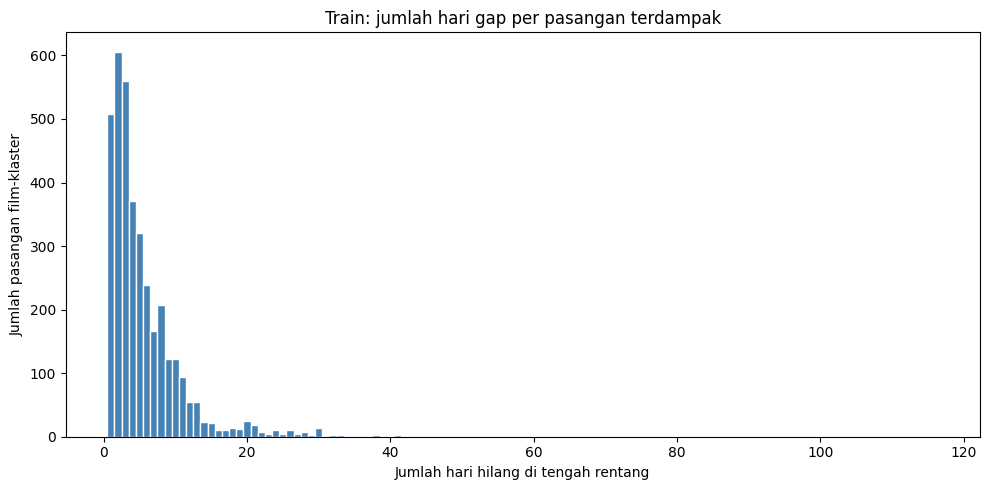

In [63]:
# Histogram of total missing interior calendar days per affected pair.
fig, ax = plt.subplots(figsize=(10, 5))
mx = int(gap_pairs19.missing_days.max())
ax.hist(gap_pairs19.missing_days, bins=np.arange(.5, mx + 1.5, 1), color="steelblue", edgecolor="white")
ax.set(title="Train: jumlah hari gap per pasangan terdampak", xlabel="Jumlah hari hilang di tengah rentang", ylabel="Jumlah pasangan film-klaster")
plt.tight_layout(); plt.show()


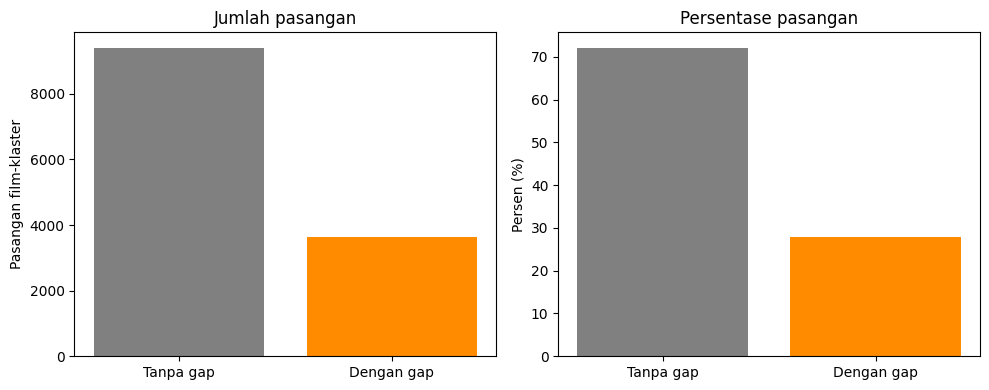

In [64]:
# Count and percentage of pairs with versus without an internal gap.
counts19 = gap_by_pair19.has_gap.value_counts().reindex([False, True], fill_value=0)
labels19 = ["Tanpa gap", "Dengan gap"]
values19 = [int(counts19.loc[False]), int(counts19.loc[True])]
pcts19 = [v / len(gap_by_pair19) * 100 for v in values19]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels19, values19, color=["gray", "darkorange"]); axes[0].set(title="Jumlah pasangan", ylabel="Pasangan film-klaster")
axes[1].bar(labels19, pcts19, color=["gray", "darkorange"]); axes[1].set(title="Persentase pasangan", ylabel="Persen (%)")
plt.tight_layout(); plt.show()


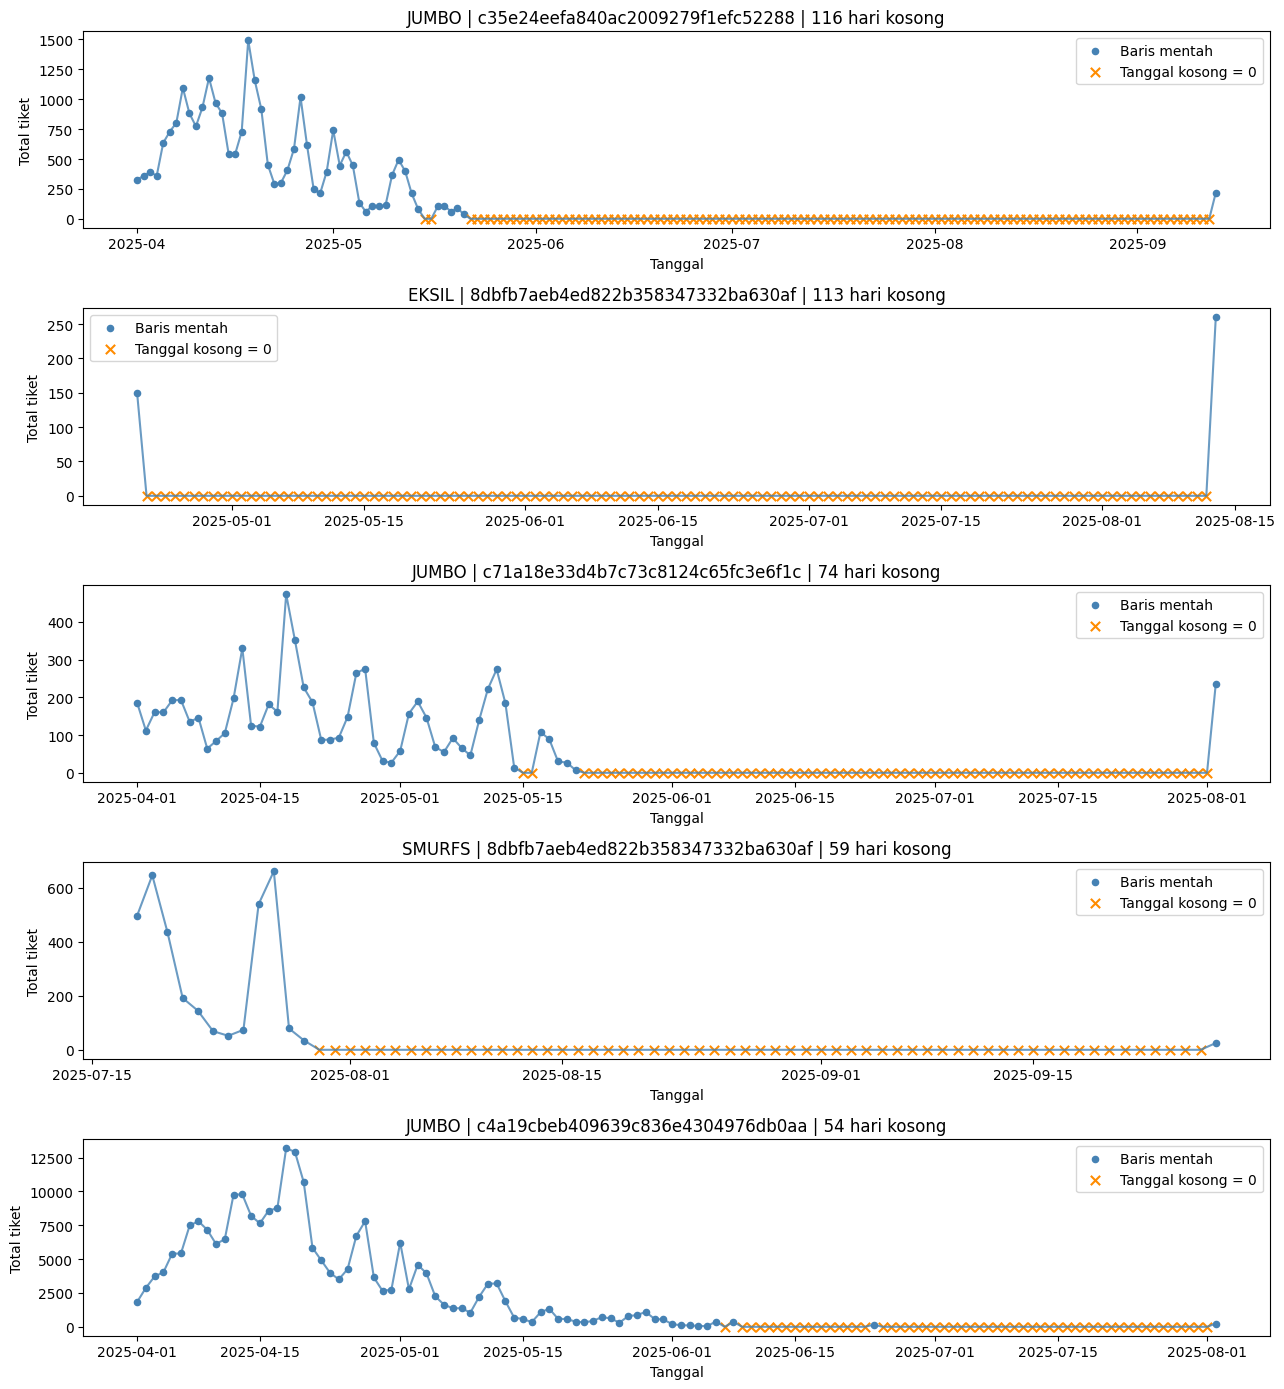

In [65]:
# Largest-gap examples; missing dates are explicitly marked as zero-valued orange Xs.
examples19 = gap_pairs19.head(5)[pair_keys19]
fig, axes = plt.subplots(len(examples19), 1, figsize=(13, 2.8 * len(examples19)), squeeze=False)
for ax, (title, cinema) in zip(axes[:, 0], examples19.itertuples(index=False, name=None)):
    raw = train19[(train19.movie_title_key == title) & (train19.cinema_ids == cinema)].sort_values("date_show")
    line = raw.set_index("date_show").total_ticket.asfreq("D", fill_value=0).rename("total_ticket").reset_index()
    line["missing"] = ~line.date_show.isin(set(raw.date_show))
    ax.plot(line.date_show, line.total_ticket, color="steelblue", alpha=.8)
    ax.scatter(line.loc[~line.missing,"date_show"], line.loc[~line.missing,"total_ticket"], s=20, color="steelblue", label="Baris mentah")
    ax.scatter(line.loc[line.missing,"date_show"], line.loc[line.missing,"total_ticket"], s=45, marker="x", color="darkorange", label="Tanggal kosong = 0")
    ax.set(title=f"{title} | {cinema} | {int(line.missing.sum())} hari kosong", xlabel="Tanggal", ylabel="Total tiket"); ax.legend()
plt.tight_layout(); plt.show()


In [66]:
# Tahap 19b: compare cluster aggregates before/after pair-calendar zero fill and inspect capacity extremes.
train19["capacity_est"] = np.where((train19.total_show > 0) & (train19.occupation_rate > 0), train19.total_ticket / (train19.total_show * train19.occupation_rate / 100), np.nan)
train19["capacity_filtered"] = train19.capacity_est.where(train19.capacity_est.between(10, 5000))
rawc = train19.groupby("cinema_ids").agg(ticket_b=("total_ticket","mean"), occ_b=("occupation_rate","mean"), show_b=("total_show","mean"), cap_b=("capacity_est","median"), cap_a=("capacity_filtered","median"))
bounds = train19.groupby(pair_keys19).date_show.agg(["min","max"])
bounds["days"] = (bounds["max"] - bounds["min"]).dt.days + 1
bounds["cinema_ids"] = bounds.index.get_level_values("cinema_ids")
denom = bounds.groupby(level="cinema_ids").days.sum()
sums = train19.groupby("cinema_ids").agg(ticket=("total_ticket","sum"), occ=("occupation_rate","sum"), show=("total_show","sum"))
cl = rawc.join(pd.DataFrame({"ticket_a":sums.ticket/denom, "occ_a":sums.occ/denom, "show_a":sums.show/denom}))
for name, before, after in [("cluster_mean_ticket","ticket_b","ticket_a"),("cluster_mean_occupation","occ_b","occ_a"),("cluster_mean_show","show_b","show_a"),("capacity_per_show","cap_b","cap_a")]:
    cl[name+"_pct"] = (cl[after]-cl[before]).abs()/cl[before].abs().replace(0,np.nan)*100
    s=cl[name+"_pct"].dropna()
    print(f"{name}: median change={s.median():.2f}%, p95={s.quantile(.95):.2f}%, clusters >5%={(s>5).sum()}/{len(s)}")
cap19=train19.capacity_est.dropna()
print(f"capacity_est n={len(cap19):,}; <10={(cap19<10).sum():,}; >5000={(cap19>5000).sum():,}; max={cap19.max():.1f}")
print("Clusters with >5% median-capacity change after filtering:", int(cl.capacity_per_show_pct.gt(5).sum()))


cluster_mean_ticket: median change=11.42%, p95=20.04%, clusters >5%=117/117
cluster_mean_occupation: median change=11.42%, p95=20.04%, clusters >5%=117/117
cluster_mean_show: median change=11.42%, p95=20.04%, clusters >5%=117/117
capacity_per_show: median change=0.00%, p95=0.01%, clusters >5%=0/117
capacity_est n=138,722; <10=0; >5000=22; max=15576.9
Clusters with >5% median-capacity change after filtering: 0


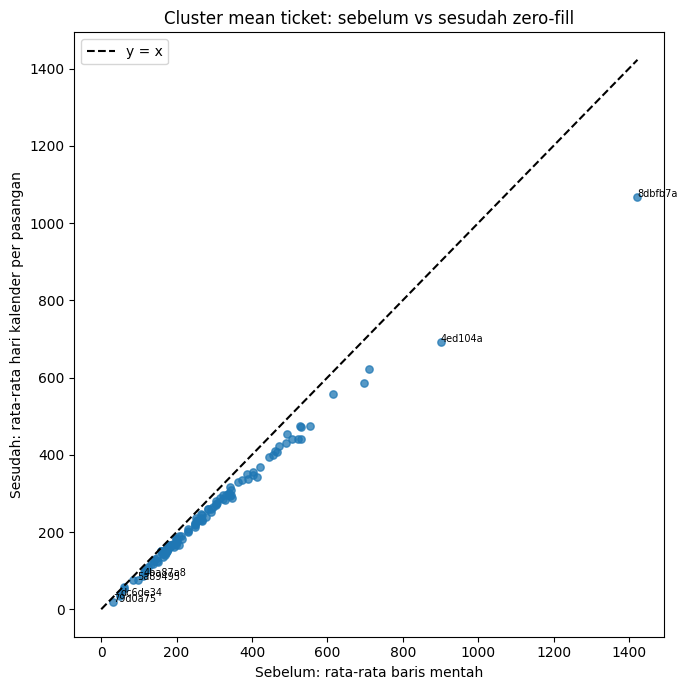

In [67]:
# Scatter: cluster mean ticket before versus after calendar zero fill.
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cl.ticket_b, cl.ticket_a, alpha=.75, s=28)
lim=max(cl.ticket_b.max(),cl.ticket_a.max()); ax.plot([0,lim],[0,lim],"k--",label="y = x")
for cid,row in cl.nlargest(6,"cluster_mean_ticket_pct").iterrows(): ax.annotate(str(cid)[:7],(row.ticket_b,row.ticket_a),fontsize=7)
ax.set(title="Cluster mean ticket: sebelum vs sesudah zero-fill",xlabel="Sebelum: rata-rata baris mentah",ylabel="Sesudah: rata-rata hari kalender per pasangan"); ax.legend()
plt.tight_layout(); plt.show()


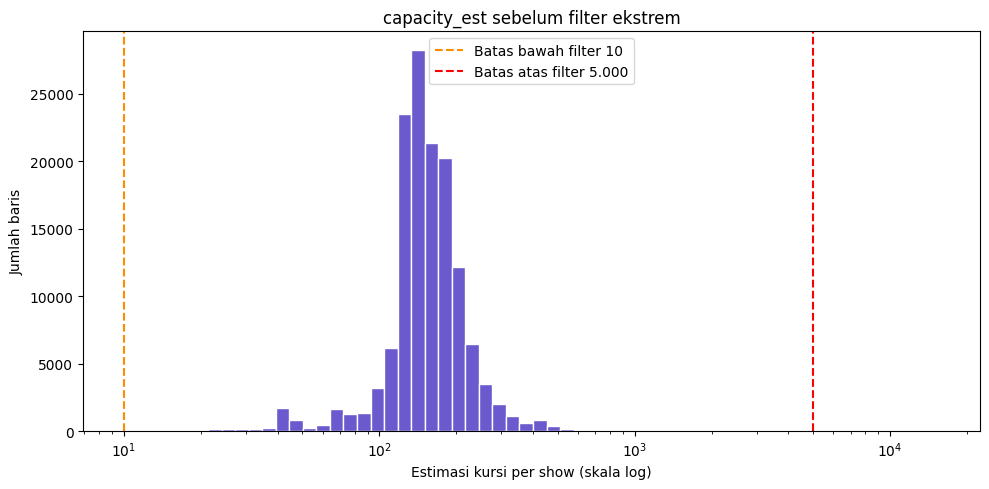

In [68]:
# Capacity histogram on a log x-axis reveals both the bulk and extreme tail.
fig, ax = plt.subplots(figsize=(10, 5))
positive=cap19[cap19>0]; bins=np.logspace(np.log10(positive.min()),np.log10(positive.max()),55)
ax.hist(positive,bins=bins,color="slateblue",edgecolor="white")
ax.axvline(10,color="darkorange",linestyle="--",label="Batas bawah filter 10")
ax.axvline(5000,color="red",linestyle="--",label="Batas atas filter 5.000")
ax.set_xscale("log"); ax.set(title="capacity_est sebelum filter ekstrem",xlabel="Estimasi kursi per show (skala log)",ylabel="Jumlah baris"); ax.legend()
plt.tight_layout(); plt.show()


In [69]:
# Tahap 19c: D1 is computed separately for each raw movie-cluster pair.
hist19=pd.read_csv(DATA/"test_history.csv",parse_dates=["date_show"])
d1pair19=hist19.groupby(["movie_title","cinema_ids"]).date_show.min().rename("d1_date").reset_index()
d1film19=d1pair19.groupby("movie_title").agg(d1_min=("d1_date","min"),d1_max=("d1_date","max"),clusters=("cinema_ids","nunique"))
d1film19["range_days"]=(d1film19.d1_max-d1film19.d1_min).dt.days
var19=d1film19[d1film19.range_days>0]
print(f"test_history: {len(d1film19)} films; {len(var19)} with D1 varying across clusters")
print("Largest D1 ranges (days):\n",d1film19.nlargest(6,"range_days")[["range_days","clusters","d1_min","d1_max"]].to_string())


test_history: 163 films; 116 with D1 varying across clusters
Largest D1 ranges (days):
                                  range_days  clusters     d1_min     d1_max
movie_title                                                                
28 YEARS LATER: THE BONE TEMPLE           2        98 2026-01-14 2026-01-16
AIR MATA DI UJUNG SAJADAH 2               2        97 2025-10-23 2025-10-25
ALAS ROBAN                                2       112 2026-01-15 2026-01-17
ANACONDA                                  2        38 2025-12-24 2025-12-26
ASRAMA PUTRI                              2        51 2026-02-19 2026-02-21
BALAS BUDI                                2        58 2026-02-05 2026-02-07


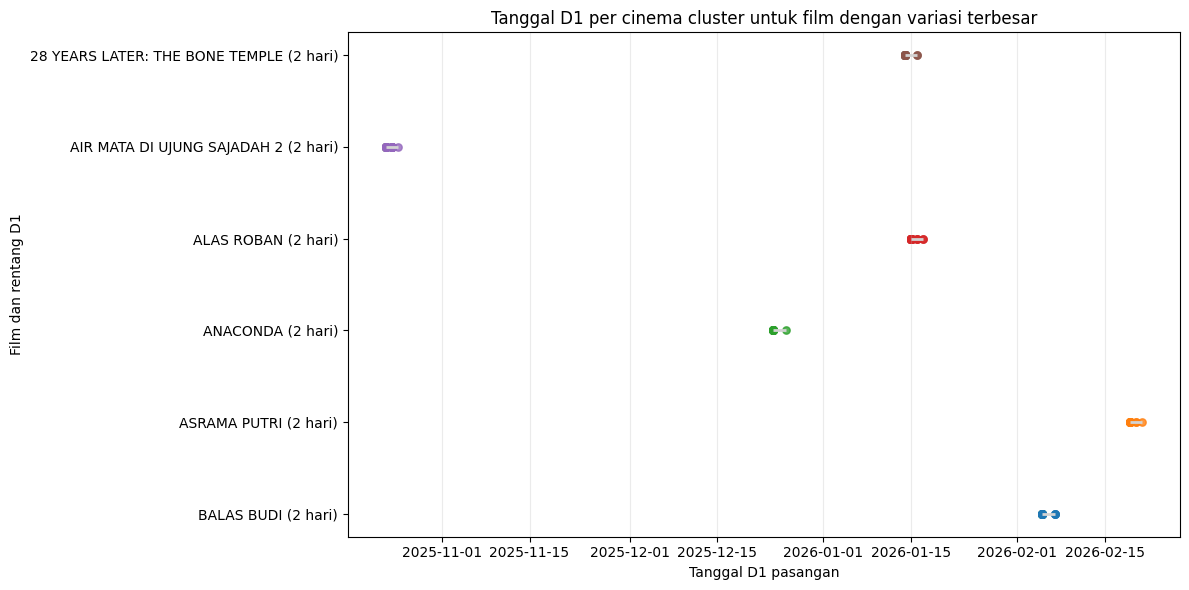

In [70]:
# Dot plot of per-cluster D1 dates for the six films with the widest spread.
order=d1film19.nlargest(6,"range_days").index.tolist()[::-1]
fig,ax=plt.subplots(figsize=(12,6))
for y,title in enumerate(order):
    rows=d1pair19[d1pair19.movie_title.eq(title)]
    ax.hlines(y,rows.d1_date.min(),rows.d1_date.max(),color="lightgray",linewidth=2)
    ax.scatter(rows.d1_date,np.full(len(rows),y),s=28,alpha=.8)
ax.set_yticks(range(len(order)),[f"{t[:42]} ({int(d1film19.loc[t,'range_days'])} hari)" for t in order])
ax.set(title="Tanggal D1 per cinema cluster untuk film dengan variasi terbesar",xlabel="Tanggal D1 pasangan",ylabel="Film dan rentang D1"); ax.grid(axis="x",alpha=.25)
plt.tight_layout(); plt.show()


In [71]:
# Tahap 19d: recheck city coverage, calendar matches, city/day prices, and exact holiday parsing.
prices19=pd.read_csv(DATA/"ticket_prices.csv")
holraw19=pd.read_csv(DATA/"holidays.csv",dtype={"date":"string"})
hdate19=pd.to_datetime(holraw19.date,format="%Y-%m-%d",errors="coerce")
parse_ok19=hdate19.notna() & hdate19.dt.strftime("%Y-%m-%d").eq(holraw19.date)
print(f"holidays.csv: {int(parse_ok19.sum())}/{len(holraw19)} exact ISO dates; parsed timezone-aware: {hdate19.dt.tz is not None}")
cal19=holraw19.assign(date=pd.to_datetime(holraw19.date,format="%Y-%m-%d",errors="coerce"))[["date","day_tipe"]]
frames19={name:pd.read_csv(DATA/f"{name}.csv",parse_dates=["date_show"]) for name in ["train","test","test_history"]}
checks=[]
for name,frame in frames19.items():
    city_missing=~frame.city_name.isin(prices19.city_name)
    joined=frame.merge(cal19,left_on="date_show",right_on="date",how="left")
    cal_missing=joined.day_tipe.isna()
    joined["price_day"]=joined.day_tipe.map({"weekday":"Weekday","friday":"Friday","weekend":"Weekend"})
    joined=joined.merge(prices19[["city_name","price_day","ceil"]],on=["city_name","price_day"],how="left")
    price_missing=joined.ceil.isna()
    print(f"{name}: {len(frame):,} rows; city missing={int(city_missing.sum())}; calendar missing={int(cal_missing.sum())}; price missing={int(price_missing.sum())}")
    checks += [{"check":f"{name}: kota","passed":int((~city_missing).sum()),"failed":int(city_missing.sum())},{"check":f"{name}: kalender","passed":int((~cal_missing).sum()),"failed":int(cal_missing.sum())},{"check":f"{name}: harga kota-hari","passed":int((~price_missing).sum()),"failed":int(price_missing.sum())}]
checks.append({"check":"holidays: tanggal ISO","passed":int(parse_ok19.sum()),"failed":int((~parse_ok19).sum())})
audit19=pd.DataFrame(checks)


holidays.csv: 366/366 exact ISO dates; parsed timezone-aware: False
train: 138,959 rows; city missing=0; calendar missing=0; price missing=0
test: 72,611 rows; city missing=0; calendar missing=0; price missing=0
test_history: 32,323 rows; city missing=0; calendar missing=0; price missing=0


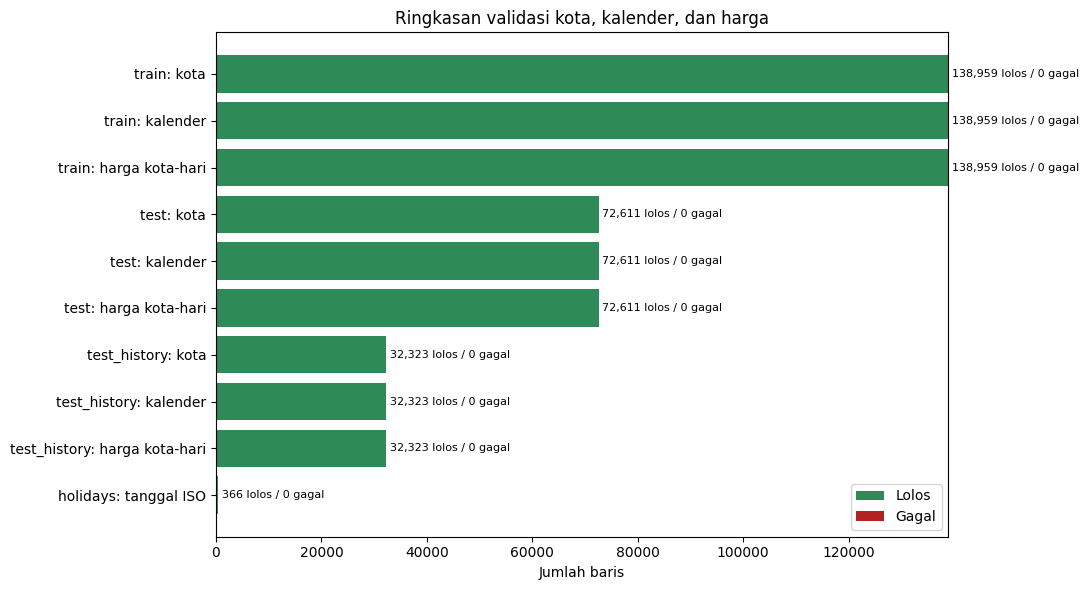

In [72]:
# Stacked row counts passing/failing each city, calendar, and price validation.
fig,ax=plt.subplots(figsize=(11,6)); y=np.arange(len(audit19))
ax.barh(y,audit19.passed,color="seagreen",label="Lolos")
ax.barh(y,audit19.failed,left=audit19.passed,color="firebrick",label="Gagal")
ax.set_yticks(y,audit19.check); ax.invert_yaxis()
ax.set(title="Ringkasan validasi kota, kalender, dan harga",xlabel="Jumlah baris")
for i,row in audit19.iterrows(): ax.text(row.passed+row.failed+max(audit19.passed.max()*.005,1),i,f"{row.passed:,} lolos / {row.failed:,} gagal",va="center",fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()
